# Prediccion de Enfermedad Renal Cronica (ERC) mediante Machine Learning
## Clasificacion Binaria Supervisada | Dataset NHANES 2021-2023

**Pregunta:** Es posible predecir la presencia de ERC a partir de variables clinicas, demograficas y de laboratorio mediante modelos de aprendizaje automatico supervisado con clasificacion binaria?

**Target:** `ckd_present` (0/1) | **Metrica:** AUC-ROC | **Dataset:** 11,933 registros

# 1. Ficha del dataset

Fuente: **CDC NHANES 2021-2023** (National Health and Nutrition Examination Survey, agosto 2021 - agosto 2023). Dataset curado en Kaggle: [CKD-NHANES 2021-2023: Staged Kidney Disease](https://www.kaggle.com/datasets/alitaqishah/ckd-nhanes-2021-2023-staged-kidney-disease). Codificaciones de las variables categoricas segun el codebook oficial del CDC ([cuestionarios NHANES](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2021-2023)).

## 1.1 Target

| Variable | Tipo | Descripcion | Valores |
|---|---|---|---|
| `ckd_present` | Binaria | Presencia de ERC segun estadiacion KDIGO 2024 (eGFR < 60 o ACR >= 30) | `0` = No CKD, `1` = CKD |

## 1.2 Variables demograficas

| Variable | Tipo | Descripcion | Valores / Significado |
|---|---|---|---|
| `age` | Numerica | Edad del participante | Años (continua) |
| `gender` | Categorica | Sexo | `Female` = Mujer, `Male` = Hombre |
| `ethnicity` | Categorica | Raza/etnia | `Mexican American`, `Other Hispanic`, `Non-Hispanic White`, `Non-Hispanic Black`, `Non-Hispanic Asian`, `Other/Multiracial` |
| `education_level` | Ordinal | Nivel educativo (DMDEDUC2) | `1` = Menos de 9o grado; `2` = 9o a 11o grado (incl. 12o sin diploma); `3` = Graduado de secundaria/GED; `4` = Algo de universidad o titulo asociado; `5` = Licenciatura o superior; `9` = No sabe |
| `poverty_income_ratio` | Numerica | Ratio de ingreso familiar respecto a la linea de pobreza | `< 1` = bajo el umbral de pobreza; `5` = ratio >= 5 (tope); continua |
| `bmi` | Numerica | Indice de masa corporal | kg/m² (continua) |

## 1.3 Variables clinicas

| Variable | Tipo | Descripcion | Valores / Significado |
|---|---|---|---|
| `bp_systolic` | Numerica | Presion arterial sistolica | mmHg (continua) |
| `bp_diastolic` | Numerica | Presion arterial diastolica | mmHg (continua) |
| `diabetes_diagnosed` | Binaria | Diabetes diagnosticada por un medico (DIQ010) | `1` = Si, `2` = No, `3` = Borderline/prediabetes, `9` = No sabe |
| `ever_smoked` | Binaria | Ha fumado al menos 100 cigarrillos en su vida (SMQ020) | `1` = Si, `2` = No, `7` = Rehusa, `9` = No sabe |

## 1.4 Variables de laboratorio

| Variable | Tipo | Descripcion | Unidades |
|---|---|---|---|
| `blood_urea_nitrogen` | Numerica | Nitrogeno ureico en sangre (BUN) | mg/dL |
| `albumin_serum` | Numerica | Albumina serica | g/dL |
| `phosphorus` | Numerica | Fosforo | mg/dL |
| `bicarbonate` | Numerica | Bicarbonato | mmol/L |
| `calcium` | Numerica | Calcio | mg/dL |
| `uric_acid` | Numerica | Acido urico | mg/dL |
| `urine_creatinine` | Numerica | Creatinina urinaria | mg/dL |
| `albumin_creatinine_ratio` | Numerica | Razon albumina/creatinina (ACR), indicador de albuminuria | mg/g |

**Nota:** el dataset original incluye variables adicionales (p. ej. `egfr`, `ckd_stage`, `serum_creatinine`, `participant_id`, `weight_kg`, `height_cm`, `insulin_use`, `diabetes_pills`, `current_smoker`, `urine_albumin`) que no se usan como entrada del modelo; su exclusion se justifica en la FASE 2.


---
# 2. Librerías

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
pd.set_option("display.max_columns", 35)
RANDOM_STATE = 42
print("Librerias OK")

Librerias OK


---
# 3. Funciones auxiliares

Logica compartida extraida de las fases para evitar duplicacion:
preprocesador, feature names, pipeline SMOTE, GridSearchCV y waterfall SHAP.

In [2]:
from collections.abc import Callable, Sequence
from dataclasses import dataclass

from sklearn.base import BaseEstimator

NumArray = np.ndarray
ParamGrid = dict[str, object]


@dataclass
class PreparedData:
    """Resultado del pipeline unico de preparacion de datos."""

    X_train: pd.DataFrame
    X_test: pd.DataFrame
    y_train: pd.Series
    y_test: pd.Series
    X_train_prep: NumArray
    X_test_prep: NumArray
    X_train_bal: NumArray
    y_train_bal: NumArray
    preprocessor: ColumnTransformer
    transform: Callable[[pd.DataFrame], NumArray]
    all_features: list[str]
    numeric_cols: list[str]
    categorical_cols: list[str]

In [3]:
def build_preprocessor(
    numeric_cols: list[str], categorical_cols: list[str]
) -> ColumnTransformer:
    """ColumnTransformer: KNNImputer + RobustScaler (num) | OneHot (cat)."""
    numeric_pipeline = Pipeline(
        [("imputer", KNNImputer(n_neighbors=5)), ("scaler", RobustScaler())]
    )
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        [
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ]
    )

In [4]:
def get_feature_names(
    preprocessor: ColumnTransformer,
    numeric_cols: list[str],
    categorical_cols: list[str],
) -> list[str]:
    """Nombres de features: numericas + one-hot de categoricas."""
    cat_names = preprocessor.named_transformers_["cat"][
        "encoder"
    ].get_feature_names_out(categorical_cols)
    return list(numeric_cols) + list(cat_names)

In [5]:
def make_smote_pipeline(clf: BaseEstimator) -> ImbPipeline:
    """ImbPipeline con SMOTE dentro de cada fold para evitar fuga."""
    return ImbPipeline([("smote", SMOTE(random_state=RANDOM_STATE)), ("clf", clf)])

In [6]:
def run_grid_search(
    clf: BaseEstimator,
    params: ParamGrid,
    X: NumArray,
    y: pd.Series,
    verbose: int = 1,
) -> GridSearchCV:
    """GridSearchCV con SMOTE intra-fold y scoring roc_auc."""
    grid = GridSearchCV(
        make_smote_pipeline(clf),
        params,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc",
        n_jobs=-1,
        verbose=verbose,
        return_train_score=True,
    )
    grid.fit(X, y)
    return grid

In [7]:
def params_sin_prefijo(grid: GridSearchCV) -> ParamGrid:
    """Parametros optimos sin el prefijo clf__ del pipeline."""
    return {k.replace("clf__", ""): v for k, v in grid.best_params_.items()}

In [8]:
def prepare_data(
    df: pd.DataFrame,
    drop_raw: Sequence[str] = (),
    drop_features: Sequence[str] = (),
    target: str = "ckd_present",
    test_size: float = 0.2,
    random_state: int = 42,
) -> PreparedData:
    """PIPELINE UNICO centralizado: split -> preprocesa -> filtra features -> SMOTE.

    drop_raw: columnas CRUDAS eliminadas antes de preprocesar (e.g. ACR).
    drop_features: nombres de FEATURES ENCODEADAS a eliminar (e.g. gender_Male).
    """
    X = df.drop(columns=[target] + list(drop_raw))
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = X_train.select_dtypes(include=["object", "str"]).columns.tolist()
    preprocessor = build_preprocessor(numeric_cols, categorical_cols)
    X_train_prep = preprocessor.fit_transform(X_train)
    X_test_prep = preprocessor.transform(X_test)
    all_features = get_feature_names(preprocessor, numeric_cols, categorical_cols)

    keep_idx = [i for i, n in enumerate(all_features) if n not in set(drop_features)]
    X_train_prep = X_train_prep[:, keep_idx]
    X_test_prep = X_test_prep[:, keep_idx]
    all_features = [all_features[i] for i in keep_idx]

    smote = SMOTE(random_state=random_state)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_prep, y_train)

    def transform(X_new: pd.DataFrame) -> NumArray:
        return preprocessor.transform(X_new)[:, keep_idx]

    return PreparedData(
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test,
        X_train_prep=X_train_prep,
        X_test_prep=X_test_prep,
        X_train_bal=X_train_bal,
        y_train_bal=y_train_bal,
        preprocessor=preprocessor,
        transform=transform,
        all_features=all_features,
        numeric_cols=numeric_cols,
        categorical_cols=categorical_cols,
    )

In [9]:
def plot_waterfall(
    shap_values,
    base_value,
    data_row,
    feature_names,
    title,
    max_display=15,
    figsize=(11, 7),
):
    """Waterfall SHAP en figura propia."""
    expl = shap.Explanation(
        values=shap_values,
        base_values=base_value,
        data=data_row,
        feature_names=feature_names,
    )
    plt.figure(figsize=figsize)
    shap.plots.waterfall(expl, show=False, max_display=max_display)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

---
# 4. Carga y exploración inicial

In [10]:
df = pd.read_csv("../data/CKD_NHANES_2021_2023.csv")
df.head()

,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,98.0,0.80,11.0,4.3,3.7,24.0,9.6,5.1,136.0,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,84.0,0.79,24.0,3.9,3.2,25.0,9.4,8.5,64.0,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,79.0,0.64,10.0,3.7,3.8,25.0,9.4,4.4,157.0,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,208.0,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  str    
 3   ethnicity                 11933 non-null  str    
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null   float64
 14  phosphorus       

In [12]:
df.describe().round(2)

,participant_id,age,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,bp_diastolic,serum_creatinine,blood_urea_nitrogen,albumin_serum,phosphorus,bicarbonate,calcium,uric_acid,urine_creatinine,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_present
count,11933.0,11933.00,7794.00,9892.00,8471.00,8754.00,8499.00,7517.00,7517.00,6326.00,6326.00,6366.00,6322.00,6325.00,6362.00,6329.00,8154.00,8153.00,8153.00,11740.00,1081.00,2281.00,8135.00,3243.00,6326.00,11933.00
mean,136344.0,38.32,3.80,2.71,27.25,70.55,159.66,119.29,72.75,0.87,14.66,4.10,3.61,24.45,9.43,5.13,133.26,35.57,33.36,1.93,1.68,1.63,1.61,2.34,96.60,0.70
std,3444.9,25.60,1.15,1.67,8.14,30.39,19.86,18.56,11.90,0.39,5.75,0.36,0.57,2.41,0.38,1.41,90.68,175.58,251.09,0.36,0.47,0.64,0.56,0.90,24.63,0.46
min,130378.0,0.00,1.00,0.00,11.10,2.70,79.10,61.00,33.00,0.33,4.00,2.20,1.60,15.00,7.50,1.10,4.00,0.21,0.08,1.00,1.00,1.00,1.00,1.00,3.51,0.00
25%,133361.0,13.00,3.00,1.18,21.60,54.20,154.40,106.00,64.00,0.70,11.00,3.90,3.20,23.00,9.20,4.10,65.00,5.77,5.42,2.00,1.00,1.00,1.00,1.00,80.50,0.00
50%,136344.0,37.00,4.00,2.50,26.40,71.70,163.60,117.00,72.00,0.83,14.00,4.10,3.60,24.00,9.40,5.00,117.00,9.62,8.27,2.00,2.00,2.00,2.00,3.00,97.03,1.00
75%,139327.0,62.00,5.00,4.50,31.70,89.10,172.10,130.00,80.00,0.98,17.00,4.30,3.90,26.00,9.70,6.00,181.00,17.83,15.33,2.00,2.00,2.00,2.00,3.00,112.66,1.00
max,142310.0,80.00,9.00,5.00,74.80,248.20,200.70,232.00,142.00,15.17,74.00,5.50,7.00,37.00,11.70,13.20,873.00,7942.47,14708.28,9.00,2.00,9.00,9.00,3.00,178.43,1.00


In [13]:
nulos = df.isnull().sum().sort_values(ascending=False)
nulos_pct = (nulos / len(df) * 100).round(1)
pd.DataFrame({"Nulos": nulos, "%": nulos_pct})[nulos > 0]

,Nulos,%
insulin_use,10852,90.9
diabetes_pills,9652,80.9
current_smoker,8690,72.8
phosphorus,5611,47.0
bicarbonate,5608,47.0
blood_urea_nitrogen,5607,47.0
serum_creatinine,5607,47.0
egfr,5607,47.0
uric_acid,5604,47.0
calcium,5571,46.7


## 4.1 Distribución del target

ckd_present
1    8341
0    3592
Name: count, dtype: int64


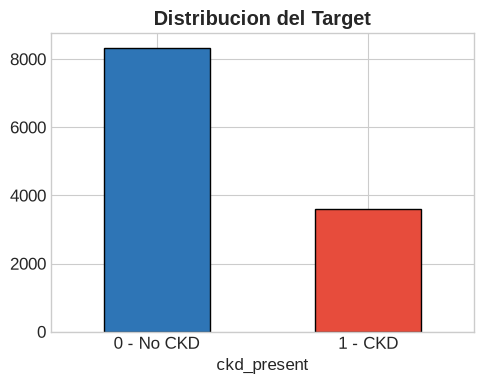

In [14]:
print(df["ckd_present"].value_counts())
fig, ax = plt.subplots(figsize=(5, 4))
df["ckd_present"].value_counts().plot(
    kind="bar", color=["#2E75B6", "#E74C3C"], edgecolor="black", ax=ax
)
ax.set_title("Distribucion del Target", fontweight="bold")
ax.set_xticklabels(["0 - No CKD", "1 - CKD"], rotation=0)
plt.tight_layout()
plt.show()

---
# 5. Eliminación de variables

| Variable | Razon | Tipo |
|---|---|---|
| `egfr` | Define el target (eGFR<60 = CKD) | Fuga directa |
| `ckd_stage` | Derivada de eGFR + ACR | Fuga directa |
| `serum_creatinine` | Insumo de CKD-EPI: eGFR=f(creatinina,edad,sexo) | Fuga proxy |
| `participant_id` | ID sin valor predictivo | N/A |
| `weight_kg`, `height_cm` | Redundantes con BMI | Redundancia |
| `insulin_use` | 91% nulos | Nulos excesivos |
| `diabetes_pills` | 81% nulos | Nulos excesivos |
| `current_smoker` | 73% nulos | Nulos excesivos |
| `urine_albumin` | Redundante con ACR (ACR = ualb/ucr) | Redundancia |

In [15]:
vars_eliminar = [
    "participant_id",
    "egfr",
    "ckd_stage",
    "serum_creatinine",
    "weight_kg",
    "height_cm",
    "insulin_use",
    "diabetes_pills",
    "current_smoker",
    "urine_albumin",
]
df_clean = df.drop(columns=vars_eliminar)

## 5.1 Filtrado
- Se hace un filtro por edad $\geq 20$, con el fin de alinear nuestro estudio a diagnostico de ERC en adultos. La ERC pediatrica es otro dominio de investigación, fuera del alcance del proyecto.

In [16]:
print(f"Registros: {len(df_clean)}")
df_clean = df_clean[df_clean["age"] >= 20].reset_index(drop=True)
print(f"Edad mayor a 20 años: {len(df_clean)} ({len(df_clean) / len(df) * 100:.1f}%)")

Registros: 11933
Edad mayor a 20 años: 7809 (65.4%)


# 6. Tratamiento de datos
## 6.1 Recodificación
### 6.1.1 Diabetes diagnosticada
- Se recodifica con encoding **ordinal** que refleja la progresion de la condicion: `0` = sin diabetes, `1` = prediabetes/borderline (estado intermedio con impacto metabolico, no equivalente a sano), `2` = diabetes diagnosticada.
- La categoria `9` (no sabe/no responde) se omite y queda como valor faltante para imputacion.


In [17]:
print("Original:", df_clean["diabetes_diagnosed"].value_counts().to_dict())
df_clean["diabetes_diagnosed"] = df_clean["diabetes_diagnosed"].replace(
    {1: 2, 2: 0, 3: 1, 9: np.nan}
)
print(
    "Recodificado:", df_clean["diabetes_diagnosed"].value_counts(dropna=False).to_dict()
)

Original: {2.0: 6466, 1.0: 1070, 3.0: 270, 9.0: 1}
Recodificado: {0.0: 6466, 2.0: 1070, 1.0: 270, nan: 3}


## 6.2 Filtrado de registros sin laboratorios

In [18]:
df_antes_filtro = df_clean.copy()
df_labs = df_clean.dropna(subset=["blood_urea_nitrogen"])
print(
    f"Registros con labs: {len(df_labs)} de {len(df_clean)} ({len(df_labs) / len(df_clean) * 100:.1f}%)"
)
print(f"Target: {df_labs['ckd_present'].value_counts().to_dict()}")
print(f"CKD: {df_labs['ckd_present'].mean() * 100:.1f}%")

Registros con labs: 5444 de 7809 (69.7%)
Target: {0: 2824, 1: 2620}
CKD: 48.1%


### 6.2.1 Porcentaje de Nulos Restante

In [19]:
nulos_post = df_labs.isnull().sum().sort_values(ascending=False)
nulos_pct_post = (nulos_post / len(df_labs) * 100).round(1)
print("Nulos restantes:")
print(pd.DataFrame({"Nulos": nulos_post, "%": nulos_pct_post})[nulos_post > 0])

Nulos restantes:
                          Nulos     %
poverty_income_ratio        700  12.9
bp_systolic                 167   3.1
bp_diastolic                167   3.1
albumin_creatinine_ratio    100   1.8
urine_creatinine            100   1.8
bmi                          72   1.3
phosphorus                   19   0.3
bicarbonate                   1   0.0
calcium                       1   0.0


## 6.3 Transformación logarítmica de variables sesgadas

In [20]:
acr_antes = df_labs["albumin_creatinine_ratio"].copy()

log_vars = ["albumin_creatinine_ratio"]
for var in log_vars:
    print(f"{var}:")
    print(f"  Skewness ANTES: {df_labs[var].skew():.2f}")
    df_labs[var] = np.log1p(df_labs[var])
    print(f"  Skewness DESPUES: {df_labs[var].skew():.2f}")

albumin_creatinine_ratio:
  Skewness ANTES: 30.67
  Skewness DESPUES: 1.52


## 6.4 Comparación ANTES vs DESPUÉS del tratamiento de datos

Boxplots lado a lado para ver el efecto de la transformacion logaritmica y la limpieza.

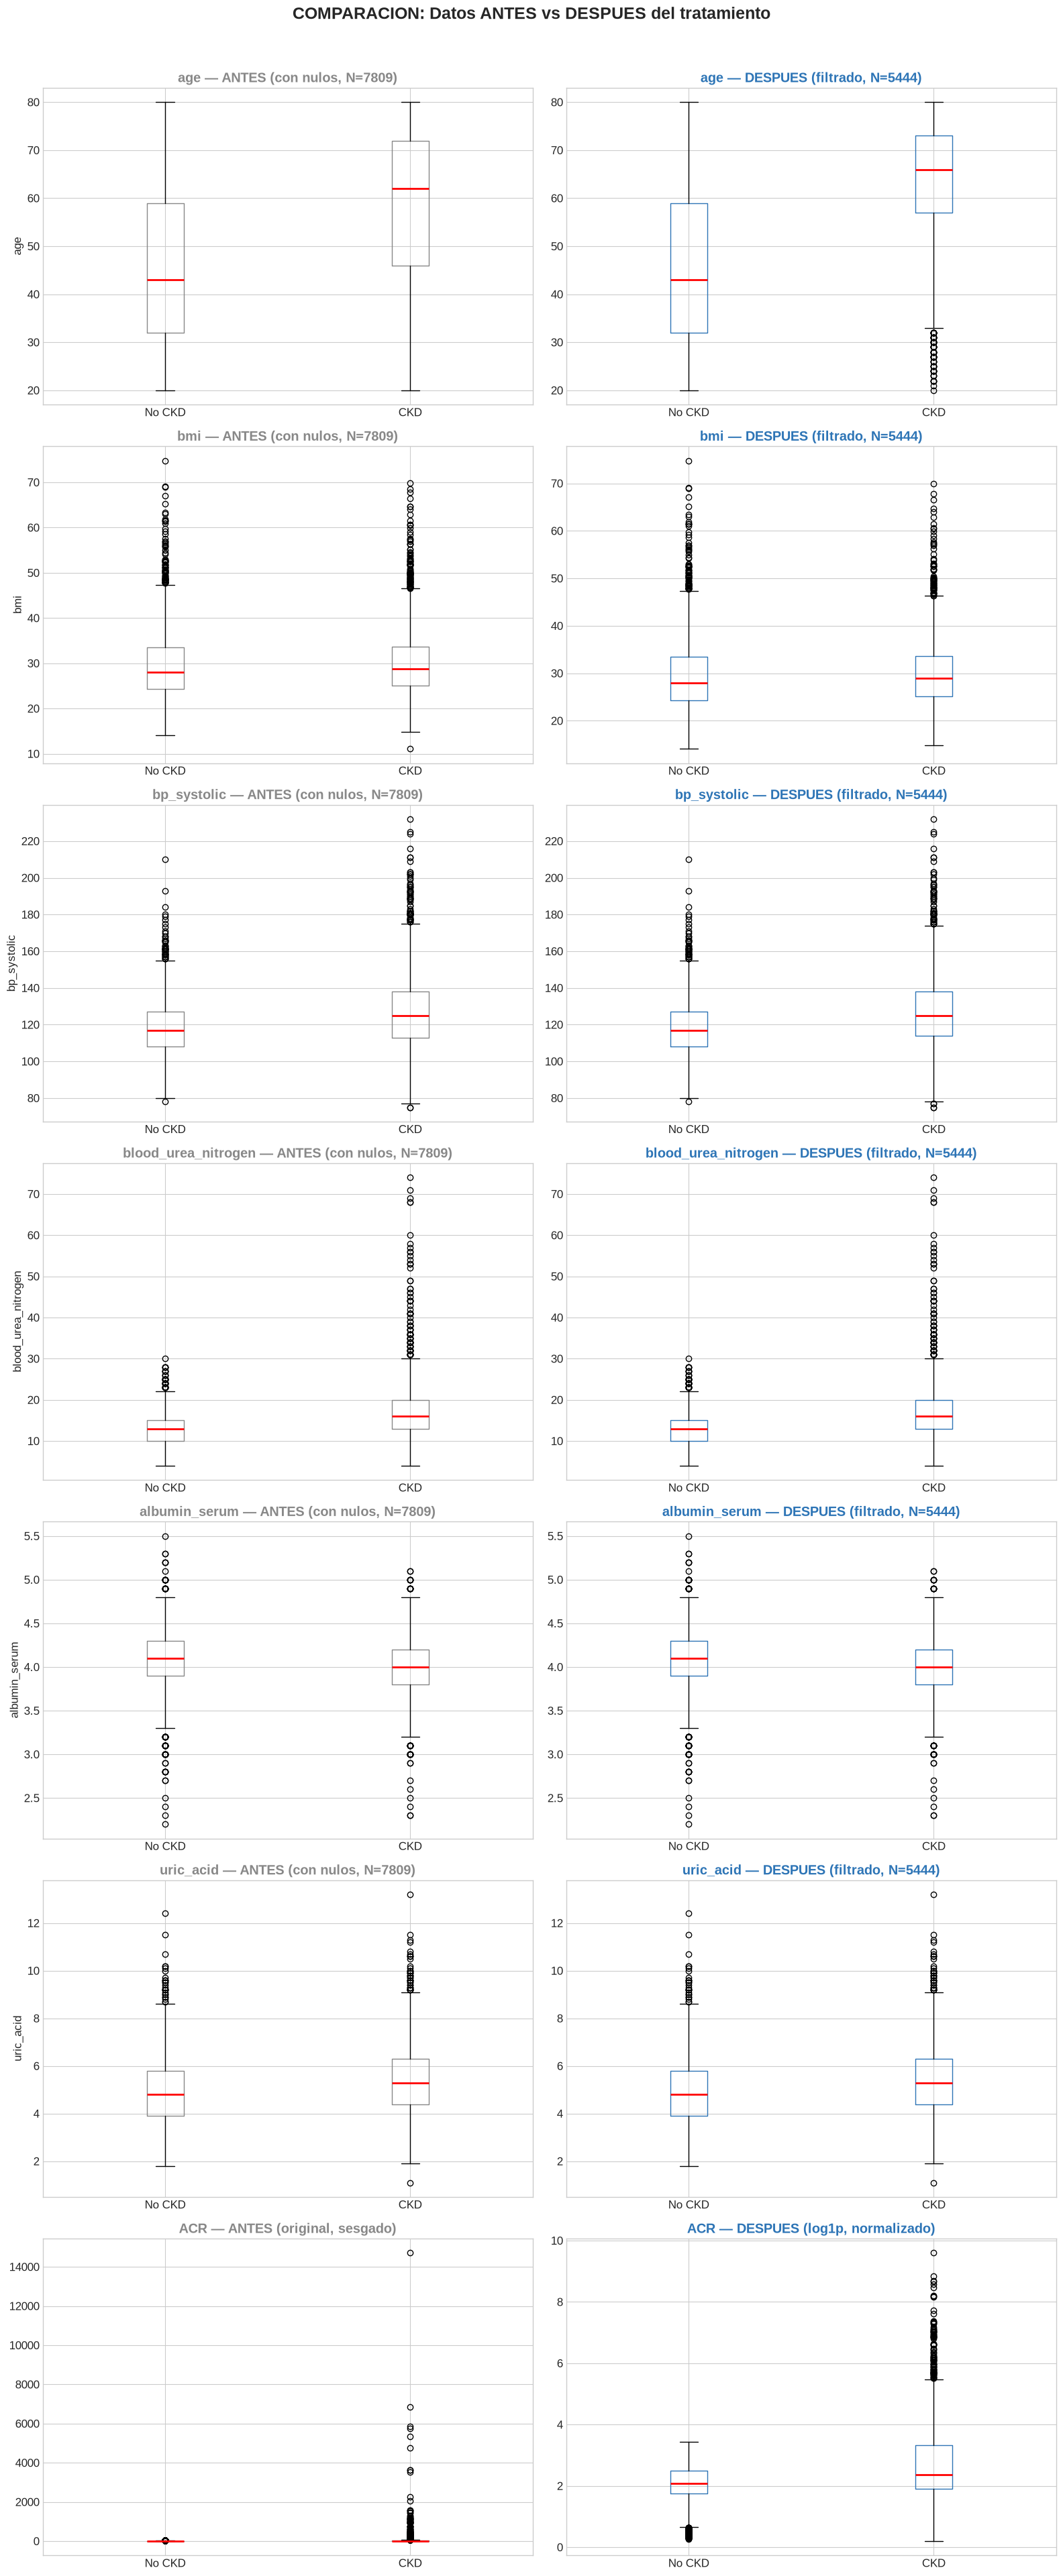

In [21]:
compare_vars = [
    "age",
    "bmi",
    "bp_systolic",
    "blood_urea_nitrogen",
    "albumin_serum",
    "uric_acid",
]

fig, axes = plt.subplots(7, 2, figsize=(16, 38))

# Variables normales: antes (df_antes_filtro) vs despues (df_labs) ---
for i, var in enumerate(compare_vars):
    row = i
    data_antes_0 = df_antes_filtro.loc[
        df_antes_filtro["ckd_present"] == 0, var
    ].dropna()
    data_antes_1 = df_antes_filtro.loc[
        df_antes_filtro["ckd_present"] == 1, var
    ].dropna()
    axes[row][0].boxplot(
        [data_antes_0, data_antes_1],
        tick_labels=["No CKD", "CKD"],
        boxprops={"color": "#888"},
        medianprops={"color": "red", "linewidth": 2},
    )
    axes[row][0].set_title(
        f"{var} — ANTES (con nulos, N={len(df_antes_filtro)})",
        fontweight="bold",
        color="#888",
    )
    axes[row][0].set_ylabel(var)

    data_desp_0 = df_labs.loc[df_labs["ckd_present"] == 0, var].dropna()
    data_desp_1 = df_labs.loc[df_labs["ckd_present"] == 1, var].dropna()
    axes[row][1].boxplot(
        [data_desp_0, data_desp_1],
        tick_labels=["No CKD", "CKD"],
        boxprops={"color": "#2E75B6"},
        medianprops={"color": "red", "linewidth": 2},
    )
    axes[row][1].set_title(
        f"{var} — DESPUES (filtrado, N={len(df_labs)})",
        fontweight="bold",
        color="#2E75B6",
    )

    if i >= 5:
        break


# ACR ANTES
d0 = acr_antes[df_labs["ckd_present"] == 0].dropna()
d1 = acr_antes[df_labs["ckd_present"] == 1].dropna()
axes[6][0].boxplot(
    [d0, d1],
    tick_labels=["No CKD", "CKD"],
    boxprops={"color": "#888"},
    medianprops={"color": "red", "linewidth": 2},
)
axes[6][0].set_title("ACR — ANTES (original, sesgado)", fontweight="bold", color="#888")

# ACR DESPUES (log)
d0l = df_labs.loc[df_labs["ckd_present"] == 0, "albumin_creatinine_ratio"].dropna()
d1l = df_labs.loc[df_labs["ckd_present"] == 1, "albumin_creatinine_ratio"].dropna()
axes[6][1].boxplot(
    [d0l, d1l],
    tick_labels=["No CKD", "CKD"],
    boxprops={"color": "#2E75B6"},
    medianprops={"color": "red", "linewidth": 2},
)
axes[6][1].set_title(
    "ACR — DESPUES (log1p, normalizado)", fontweight="bold", color="#2E75B6"
)

plt.suptitle(
    "COMPARACION: Datos ANTES vs DESPUES del tratamiento",
    fontsize=18,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

---
# 7. EDA sobre datos tratados

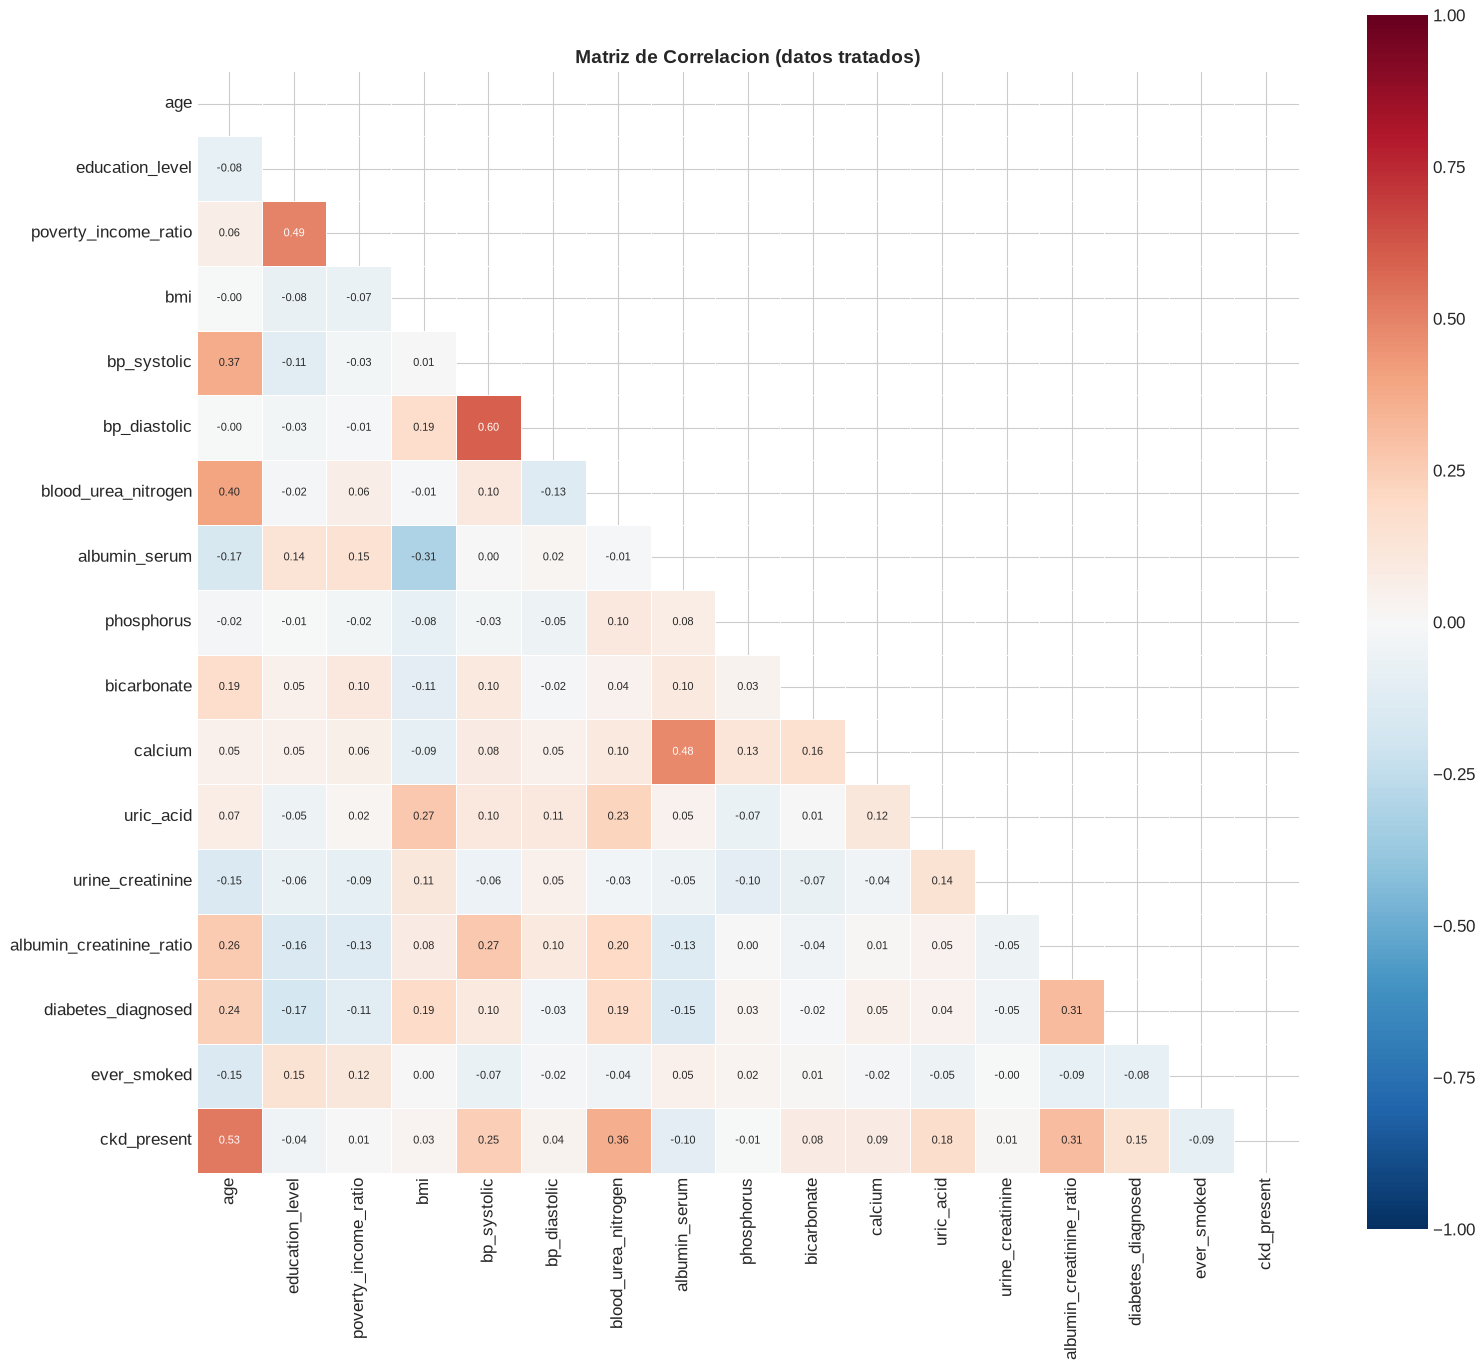

In [22]:
# Matriz de correlacion
num_data = df_labs.select_dtypes(include=[np.number])
corr = num_data.corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8},
)
plt.title("Matriz de Correlacion (datos tratados)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

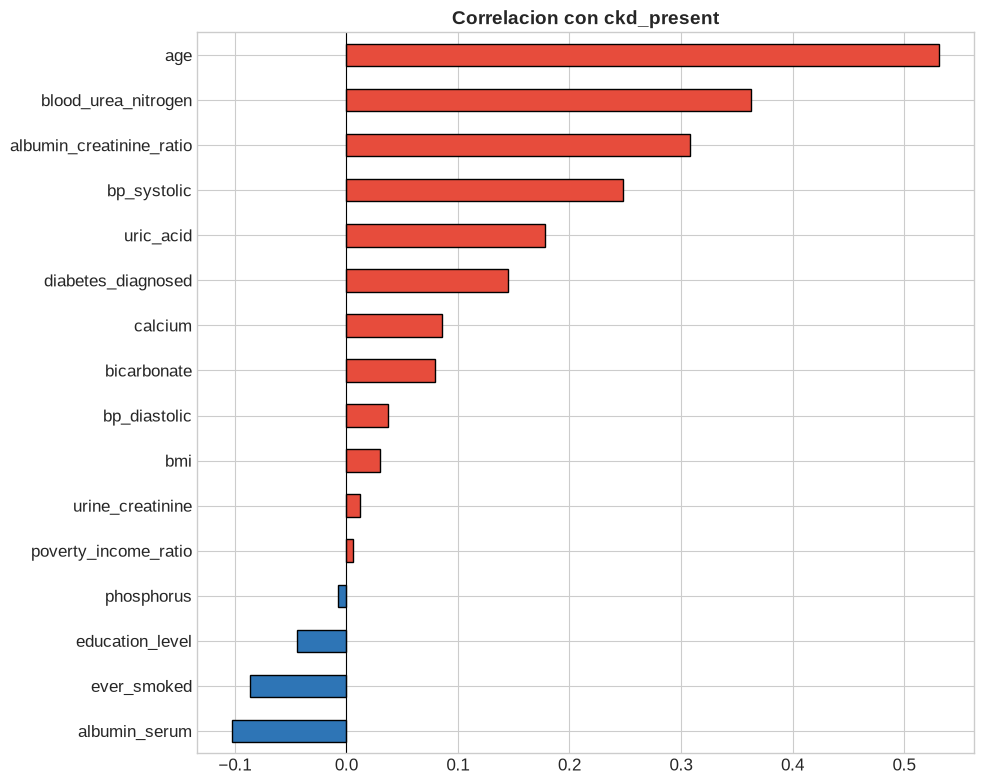

In [23]:
# Correlacion con target
corr_target = num_data.corr()["ckd_present"].drop("ckd_present").sort_values()
plt.figure(figsize=(10, 8))
colors = ["#E74C3C" if x > 0 else "#2E75B6" for x in corr_target.values]
corr_target.plot(kind="barh", color=colors, edgecolor="black")
plt.title("Correlacion con ckd_present", fontsize=14, fontweight="bold")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

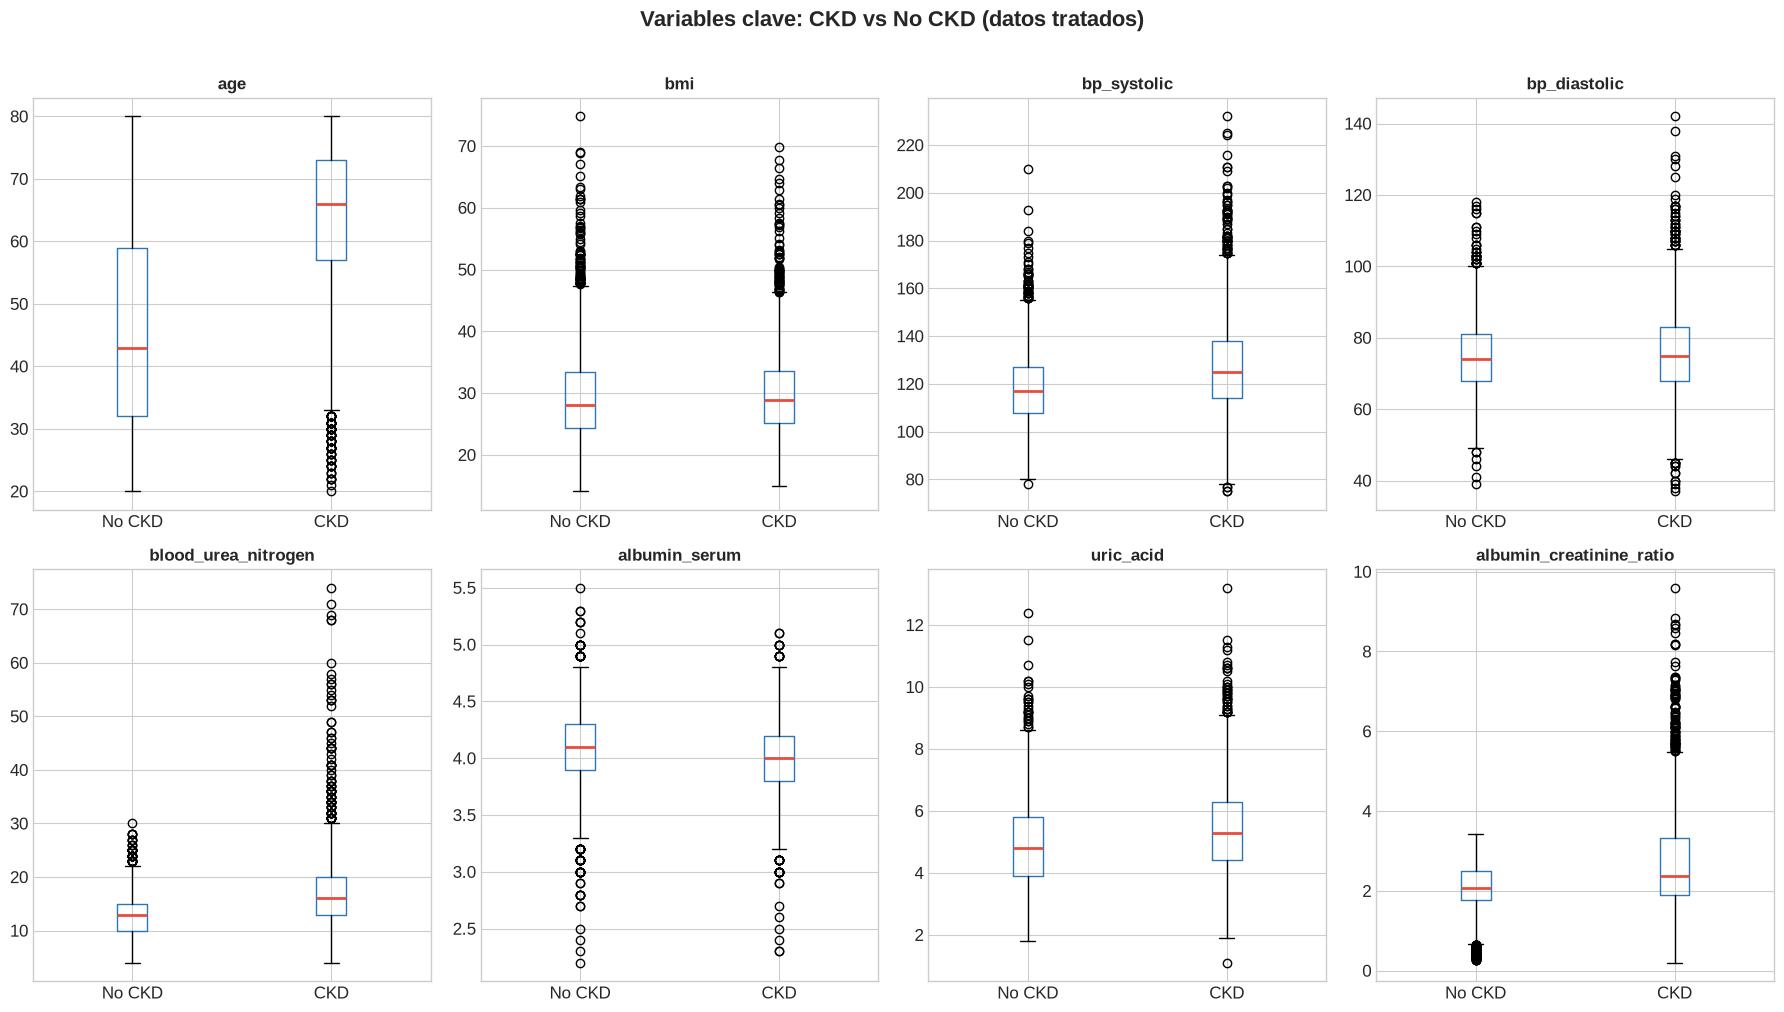

In [24]:
# Boxplots limpios finales
key_vars = [
    "age",
    "bmi",
    "bp_systolic",
    "bp_diastolic",
    "blood_urea_nitrogen",
    "albumin_serum",
    "uric_acid",
    "albumin_creatinine_ratio",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(key_vars):
    ax = axes[i]
    d0 = df_labs.loc[df_labs["ckd_present"] == 0, col].dropna()
    d1 = df_labs.loc[df_labs["ckd_present"] == 1, col].dropna()
    ax.boxplot(
        [d0, d1],
        tick_labels=["No CKD", "CKD"],
        boxprops={"color": "#2E75B6"},
        medianprops={"color": "#E74C3C", "linewidth": 2},
    )
    ax.set_title(col, fontsize=12, fontweight="bold")
plt.suptitle(
    "Variables clave: CKD vs No CKD (datos tratados)",
    fontsize=16,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

## 7.1 Selección de variables con Lasso

Lasso aplica penalizacion L1 que lleva los coeficientes de las variables poco utiles a 0, permitiendo identificar que variables aportan a la clasificacion de ERC y cuales pueden descartarse. Se usa **RobustScaler** por la cantidad de outliers en los datos.

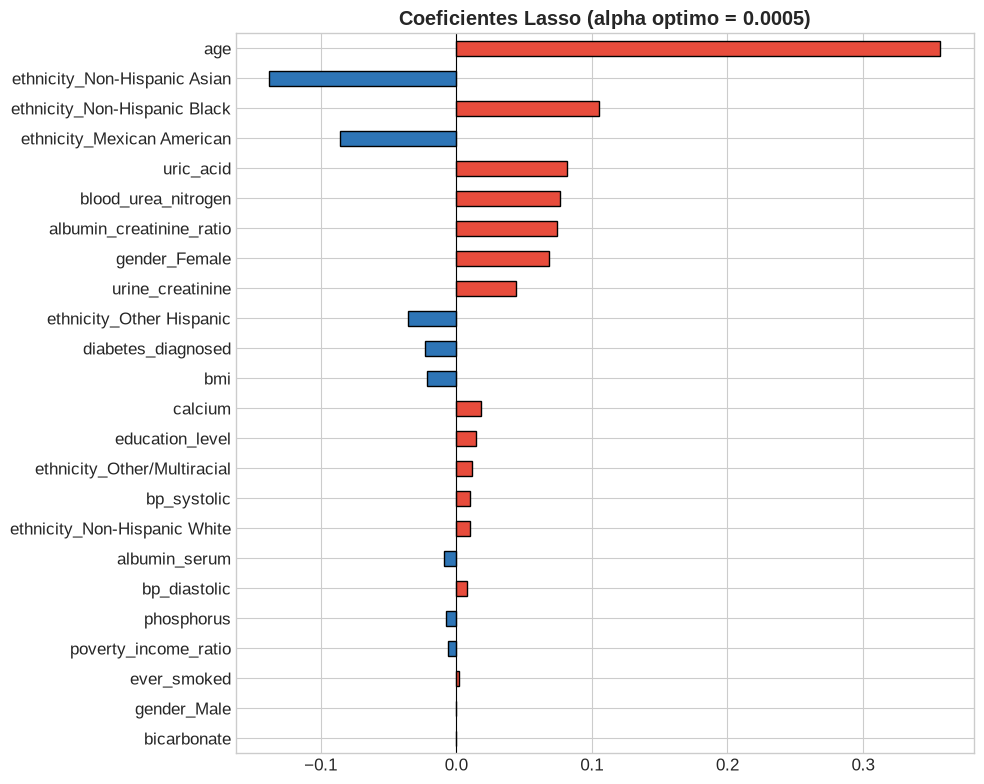

Variables eliminadas por Lasso (coef = 0): ['bicarbonate']


In [25]:
lasso_num = (
    df_labs.select_dtypes(include=[np.number])
    .drop(columns=["ckd_present"])
    .columns.tolist()
)
lasso_cat = df_labs.select_dtypes(include=["object", "str"]).columns.tolist()

prep_lasso = ColumnTransformer(
    [
        (
            "num",
            Pipeline(
                [("imp", SimpleImputer(strategy="median")), ("scl", RobustScaler())]
            ),
            lasso_num,
        ),
        (
            "cat",
            Pipeline(
                [
                    ("imp", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                    ),
                ]
            ),
            lasso_cat,
        ),
    ]
)

X_lasso = prep_lasso.fit_transform(df_labs)
y_lasso = df_labs["ckd_present"].values

lasso = LassoCV(cv=5, random_state=42, max_iter=100000, n_jobs=-1)
lasso.fit(X_lasso, y_lasso)

feat_names = get_feature_names(prep_lasso, lasso_num, lasso_cat)
coef = pd.Series(lasso.coef_, index=feat_names).sort_values(key=lambda s: s.abs())

plt.figure(figsize=(10, 8))
colors = ["#E74C3C" if x > 0 else "#2E75B6" for x in coef.values]
coef.plot(kind="barh", color=colors, edgecolor="black")
plt.title(f"Coeficientes Lasso (alpha optimo = {lasso.alpha_:.4f})", fontweight="bold")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

desechables = coef[coef == 0].index.tolist()
print("Variables eliminadas por Lasso (coef = 0):", desechables)

## Variables a eliminar del modelo
- Se tiene en cuenta el resultado obtenido por Lasso.

In [26]:
vars_descartar = ["gender_Male", "bicarbonate"]
print(f"Eliminadas (features encodeadas): {vars_descartar}")

Eliminadas (features encodeadas): ['gender_Male', 'bicarbonate']


---
# 8. Preprocesamiento, Split y Balanceo

In [27]:
# PIPELINE UNICO (seccion 3): split -> preprocesa -> filtra features -> SMOTE
data: PreparedData = prepare_data(df_labs, drop_features=vars_descartar)

X_train, X_test, y_train, y_test = data.X_train, data.X_test, data.y_train, data.y_test
numeric_cols, categorical_cols = data.numeric_cols, data.categorical_cols
preprocessor, transform = data.preprocessor, data.transform
X_train_prep, X_test_prep = data.X_train_prep, data.X_test_prep
X_train_bal, y_train_bal = data.X_train_bal, data.y_train_bal
all_features = data.all_features

print(f"Train: {X_train.shape[0]} ({y_train.mean() * 100:.1f}% CKD)")
print(f"Test:  {X_test.shape[0]} ({y_test.mean() * 100:.1f}% CKD)")

Train: 4355 (48.1% CKD)
Test:  1089 (48.1% CKD)


In [28]:
print(f"Numericas ({len(numeric_cols)}): {numeric_cols}")
print(f"Categoricas ({len(categorical_cols)}): {categorical_cols}")

Numericas (16): ['age', 'education_level', 'poverty_income_ratio', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked']
Categoricas (2): ['gender', 'ethnicity']


In [29]:
print(f"Features encodeadas tras filtrar {vars_descartar}: {X_train_prep.shape[1]}")
print(
    f"Nulos train: {np.isnan(X_train_prep).sum()} | Nulos test: {np.isnan(X_test_prep).sum()}"
)
print(f"Feature names: {all_features}")

Features encodeadas tras filtrar ['gender_Male', 'bicarbonate']: 22
Nulos train: 0 | Nulos test: 0
Feature names: ['age', 'education_level', 'poverty_income_ratio', 'bmi', 'bp_systolic', 'bp_diastolic', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'calcium', 'uric_acid', 'urine_creatinine', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'ever_smoked', 'gender_Female', 'ethnicity_Mexican American', 'ethnicity_Non-Hispanic Asian', 'ethnicity_Non-Hispanic Black', 'ethnicity_Non-Hispanic White', 'ethnicity_Other Hispanic', 'ethnicity_Other/Multiracial']


ANTES:  No CKD=2259 | CKD=2096
DESPUES: No CKD=2259 | CKD=2259


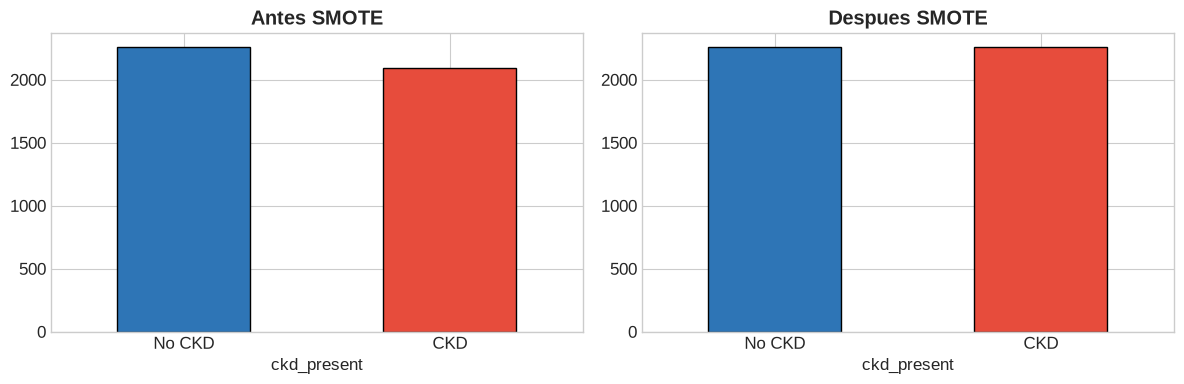

In [30]:
print(f"ANTES:  No CKD={(y_train == 0).sum()} | CKD={(y_train == 1).sum()}")
print(f"DESPUES: No CKD={(y_train_bal == 0).sum()} | CKD={(y_train_bal == 1).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.Series(y_train).value_counts().plot(
    kind="bar", ax=axes[0], color=["#2E75B6", "#E74C3C"], edgecolor="black"
)
axes[0].set_title("Antes SMOTE", fontweight="bold")
axes[0].set_xticklabels(["No CKD", "CKD"], rotation=0)
pd.Series(y_train_bal).value_counts().plot(
    kind="bar", ax=axes[1], color=["#2E75B6", "#E74C3C"], edgecolor="black"
)
axes[1].set_title("Despues SMOTE", fontweight="bold")
axes[1].set_xticklabels(["No CKD", "CKD"], rotation=0)
plt.tight_layout()
plt.show()

---
# 9. Entrenamiento de modelos base + Cross-Validation

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=15, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
    ),
}

## 9.1 Entrenamiento de los modelos

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_validate(
        make_smote_pipeline(model),
        X_train_prep,
        y_train,
        cv=cv,
        scoring=["roc_auc", "f1", "accuracy", "recall"],
        n_jobs=-1,
    )
    results[name] = {
        "AUC-ROC": f"{scores['test_roc_auc'].mean():.4f} (+/- {scores['test_roc_auc'].std():.4f})",
        "F1": f"{scores['test_f1'].mean():.4f} (+/- {scores['test_f1'].std():.4f})",
        "Accuracy": f"{scores['test_accuracy'].mean():.4f} (+/- {scores['test_accuracy'].std():.4f})",
        "Recall": f"{scores['test_recall'].mean():.4f} (+/- {scores['test_recall'].std():.4f})",
        "AUC_mean": scores["test_roc_auc"].mean(),
    }

pd.DataFrame(results).T.drop(columns=["AUC_mean"])

,AUC-ROC,F1,Accuracy,Recall
Logistic Regression,0.8653 (+/- 0.0151),0.7764 (+/- 0.0158),0.7825 (+/- 0.0126),0.7853 (+/- 0.0264)
Random Forest,0.8861 (+/- 0.0122),0.7890 (+/- 0.0144),0.7970 (+/- 0.0109),0.7896 (+/- 0.0275)
XGBoost,0.8823 (+/- 0.0119),0.7925 (+/- 0.0166),0.8039 (+/- 0.0120),0.7796 (+/- 0.0317)


---
# 10. Optimización de hiperparámetros (GridSearchCV)

Random Forest y XGBoost estan muy cerca (~0.93 AUC). Con GridSearch buscamos la mejor combinacion de hiperparametros para cada uno.

In [33]:
rf_params = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [10, 15, 20, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
}

rf_grid = run_grid_search(
    RandomForestClassifier(random_state=42), rf_params, X_train_prep, y_train
)

t0 = time.time()
rf_grid.fit(X_train_prep, y_train)
t_rf = time.time() - t0

print(f"Tiempo: {t_rf:.1f}s")
print(f"Mejor AUC-ROC: {rf_grid.best_score_:.4f}")
print(f"Mejores parametros: {rf_grid.best_params_}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Tiempo: 69.3s
Mejor AUC-ROC: 0.8869
Mejores parametros: {'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}


In [34]:
xgb_params = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [4, 6, 8],
    "clf__learning_rate": [0.05, 0.1, 0.2],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0],
}

xgb_grid = run_grid_search(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=1,
    ),
    xgb_params,
    X_train_prep,
    y_train,
)

t0 = time.time()
xgb_grid.fit(X_train_prep, y_train)
t_xgb = time.time() - t0

print(f"Tiempo: {t_xgb:.1f}s")
print(f"Mejor AUC-ROC: {xgb_grid.best_score_:.4f}")
print(f"Mejores parametros: {xgb_grid.best_params_}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Tiempo: 26.8s
Mejor AUC-ROC: 0.8961
Mejores parametros: {'clf__colsample_bytree': 0.8, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 200, 'clf__subsample': 0.8}


## 10.1 Comparación antes y después de hacer GridSearch

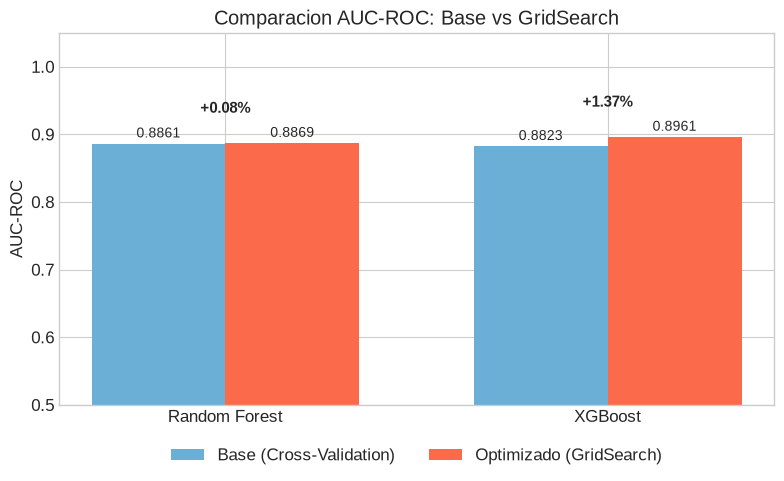

In [35]:
modelos = ["Random Forest", "XGBoost"]
base = [results["Random Forest"]["AUC_mean"], results["XGBoost"]["AUC_mean"]]
opt = [rf_grid.best_score_, xgb_grid.best_score_]
mejora = [(o - b) * 100 for b, o in zip(base, opt)]
x = np.arange(len(modelos))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(
    x - width / 2, base, width, label="Base (Cross-Validation)", color="#6baed6"
)
b2 = ax.bar(x + width / 2, opt, width, label="Optimizado (GridSearch)", color="#fb6a4a")

ax.set_ylabel("AUC-ROC")
ax.set_title("Comparacion AUC-ROC: Base vs GridSearch")
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.set_ylim(0.5, 1.05)

for rects in (b1, b2):
    for rect in rects:
        ax.text(
            rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.005,
            f"{rect.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

for i, mej in enumerate(mejora):
    ax.text(
        i, opt[i] + 0.045, f"+{mej:.2f}%", ha="center", fontsize=11, fontweight="bold"
    )

ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

In [36]:
if rf_grid.best_score_ >= xgb_grid.best_score_:
    best_model = rf_grid.best_estimator_
    best_name = "Random Forest (optimizado)"
    best_auc_cv = rf_grid.best_score_
else:
    best_model = xgb_grid.best_estimator_
    best_name = "XGBoost (optimizado)"
    best_auc_cv = xgb_grid.best_score_

print(f"MEJOR MODELO FINAL: {best_name} (AUC CV = {best_auc_cv:.4f})")

MEJOR MODELO FINAL: XGBoost (optimizado) (AUC CV = 0.8961)


---
# 11. Evaluación final en Test Set

In [37]:
y_pred = best_model.predict(X_test_prep)
y_prob = best_model.predict_proba(X_test_prep)[:, 1]

print(f"Modelo: {best_name}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR:  {average_precision_score(y_test, y_prob):.4f}")
print(f"{classification_report(y_test, y_pred, target_names=['No CKD', 'CKD'])}")

Modelo: XGBoost (optimizado)
AUC-ROC: 0.8804
AUC-PR:  0.8881
              precision    recall  f1-score   support

      No CKD       0.80      0.80      0.80       565
         CKD       0.78      0.78      0.78       524

    accuracy                           0.79      1089
   macro avg       0.79      0.79      0.79      1089
weighted avg       0.79      0.79      0.79      1089



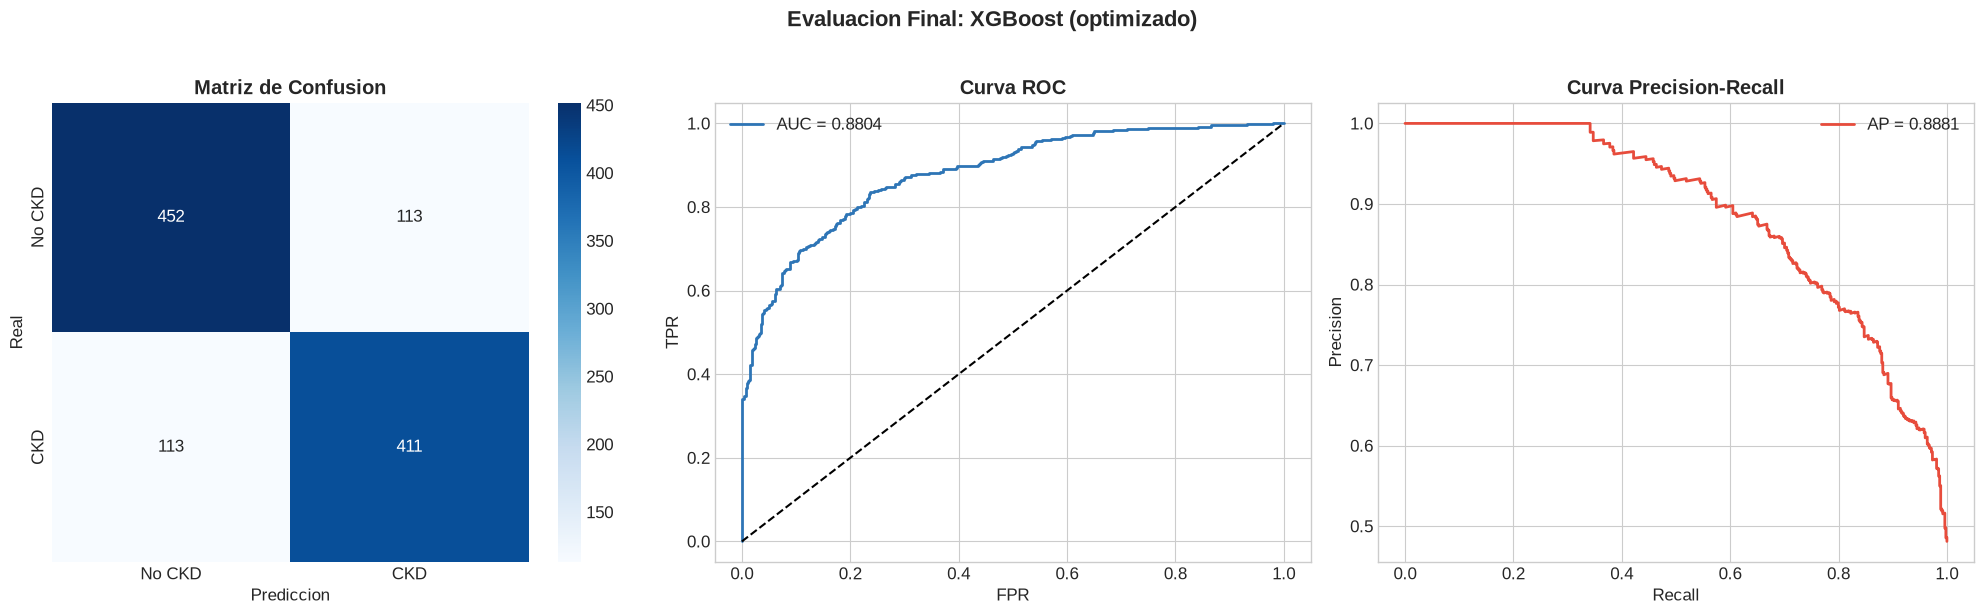

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["No CKD", "CKD"],
    yticklabels=["No CKD", "CKD"],
)
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de Confusion", fontweight="bold")

fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(
    fpr,
    tpr,
    color="#2E75B6",
    linewidth=2,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}",
)
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("Curva ROC", fontweight="bold")
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[2].plot(
    rec,
    prec,
    color="#E74C3C",
    linewidth=2,
    label=f"AP = {average_precision_score(y_test, y_prob):.4f}",
)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Curva Precision-Recall", fontweight="bold")
axes[2].legend()

plt.suptitle(f"Evaluacion Final: {best_name}", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 11.1 Análisis de sensibilidad
- $\text{ACR} \geq 30$  es criterio diagnostico de CKD (KDIGO), lo que representa una fuga parcial.
- Por ello, planeteamos reentrenar el mejor modelo obtenido, que fue XGBoost sin `albumin_creatinine_ratio`
sobre el MISMO split y cuantificar la caida de AUC.

In [39]:
vars_fuga = ["albumin_creatinine_ratio"]
data_s: PreparedData = prepare_data(
    df_labs, drop_raw=vars_fuga, drop_features=vars_descartar
)

X_train_s, X_test_s, y_train_s, y_test_s = (
    data_s.X_train,
    data_s.X_test,
    data_s.y_train,
    data_s.y_test,
)
numeric_s, categorical_s = data_s.numeric_cols, data_s.categorical_cols
prep_sens, transform_s = data_s.preprocessor, data_s.transform
X_train_s_prep, X_test_s_prep = data_s.X_train_prep, data_s.X_test_prep
X_train_s_bal, y_train_s_bal = data_s.X_train_bal, data_s.y_train_bal
all_features_s = data_s.all_features

In [40]:
print(f"Train sens: {X_train_s.shape[0]} ({y_train_s.mean() * 100:.1f}% CKD)")
print(f"Test sens:  {X_test_s.shape[0]} ({y_test_s.mean() * 100:.1f}% CKD)")

Train sens: 4355 (48.1% CKD)
Test sens:  1089 (48.1% CKD)


In [41]:
print(f"Features sens tras filtrar: {X_train_s_prep.shape[1]}")
print(f"Eliminadas en sensibilidad: {vars_fuga + vars_descartar}")

Features sens tras filtrar: 21
Eliminadas en sensibilidad: ['albumin_creatinine_ratio', 'gender_Male', 'bicarbonate']


In [42]:
print(f"SMOTE sens: {X_train_s_bal.shape[0]} filas | CKD={y_train_s_bal.sum()}")

SMOTE sens: 4518 filas | CKD=2259


In [43]:
# XGBoost con los mismos hiperparametros del grid
xgb_params_s = params_sin_prefijo(xgb_grid)
xgb_sens = XGBClassifier(**xgb_params_s)
xgb_sens.fit(X_train_s_bal, y_train_s_bal)

# Evaluar en el MISMO test
prob_sens = xgb_sens.predict_proba(X_test_s_prep)[:, 1]
auc_sens = roc_auc_score(y_test_s, prob_sens)
ap_sens = average_precision_score(y_test_s, prob_sens)

# AUC con ACR: MISMO modelo (XGBoost optimizado) y mismo test
xgb_prob = xgb_grid.best_estimator_.predict_proba(X_test_prep)[:, 1]
auc_full = roc_auc_score(y_test, xgb_prob)
ap_full = average_precision_score(y_test, xgb_prob)
caida = auc_full - auc_sens
print(f"AUC-ROC con ACR:      {auc_full:.4f}")
print(f"AUC-ROC sin ACR:      {auc_sens:.4f}")
print(f"Caida:                {caida:.4f} ({caida / auc_full * 100:.1f}%)")
print(f"AUC-PR con ACR:       {ap_full:.4f}")
print(f"AUC-PR sin ACR:       {ap_sens:.4f}")

AUC-ROC con ACR:      0.8804
AUC-ROC sin ACR:      0.8207
Caida:                0.0597 (6.8%)
AUC-PR con ACR:       0.8881
AUC-PR sin ACR:       0.8242


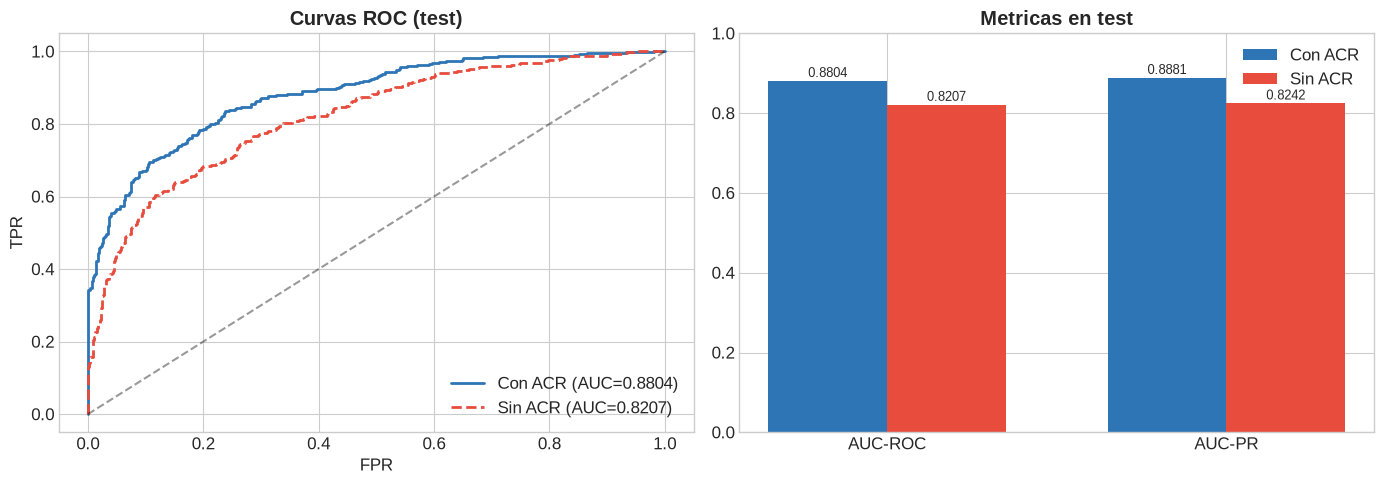

In [44]:
# Grafico: ROC superpuestas + barras comparativas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_f, tpr_f, _ = roc_curve(y_test, xgb_prob)
fpr_s, tpr_s, _ = roc_curve(y_test_s, prob_sens)
axes[0].plot(fpr_f, tpr_f, color="#2E75B6", lw=2, label=f"Con ACR (AUC={auc_full:.4f})")
axes[0].plot(
    fpr_s,
    tpr_s,
    color="#E74C3C",
    lw=2,
    ls="--",
    label=f"Sin ACR (AUC={auc_sens:.4f})",
)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR")
axes[0].set_ylabel("TPR")
axes[0].set_title("Curvas ROC (test)", fontweight="bold")
axes[0].legend()

labels = ["AUC-ROC", "AUC-PR"]
vals_con = [auc_full, ap_full]
vals_sin = [auc_sens, ap_sens]
x = np.arange(2)
w = 0.35
b1 = axes[1].bar(x - w / 2, vals_con, w, color="#2E75B6", label="Con ACR")
b2 = axes[1].bar(x + w / 2, vals_sin, w, color="#E74C3C", label="Sin ACR")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylim(0, 1)
axes[1].set_title("Metricas en test", fontweight="bold")
axes[1].legend()
for bars in (b1, b2):
    for b in bars:
        axes[1].text(
            b.get_x() + b.get_width() / 2,
            b.get_height() + 0.01,
            f"{b.get_height():.4f}",
            ha="center",
            fontsize=9,
        )
plt.tight_layout()
plt.show()

---
# 12. Interpretabilidad con SHAP

In [45]:
# TreeExplainer para modelos basados en arboles
explainer = shap.TreeExplainer(best_model.named_steps["clf"])
shap_values = explainer.shap_values(X_test_prep)

# Ajustar segun tipo
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
    base_val = explainer.expected_value[1]
else:
    shap_vals = shap_values
    base_val = explainer.expected_value

print(f"SHAP values: {shap_vals.shape}")

SHAP values: (1089, 22)


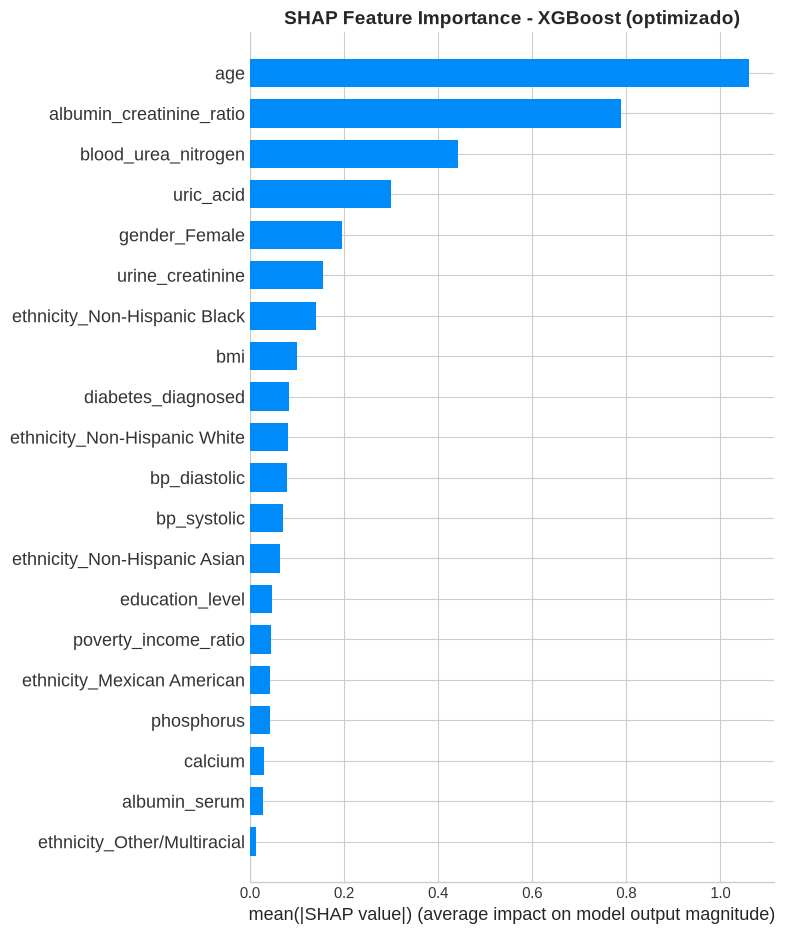

In [46]:
# Bar plot (importancia global)
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals,
    X_test_prep,
    feature_names=all_features,
    plot_type="bar",
    show=False,
    max_display=20,
)
plt.title(f"SHAP Feature Importance - {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

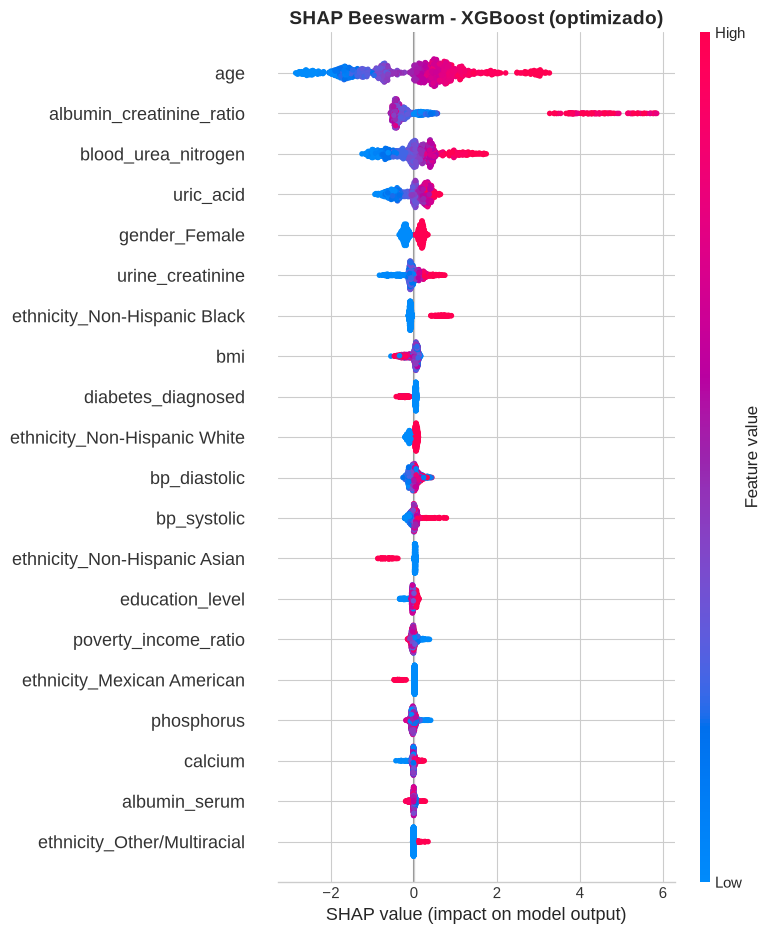

In [47]:
# Beeswarm plot (importancia + direccion)
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_vals, X_test_prep, feature_names=all_features, show=False, max_display=20
)
plt.title(f"SHAP Beeswarm - {best_name}", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 12.1 Top 10 Variables SHAP

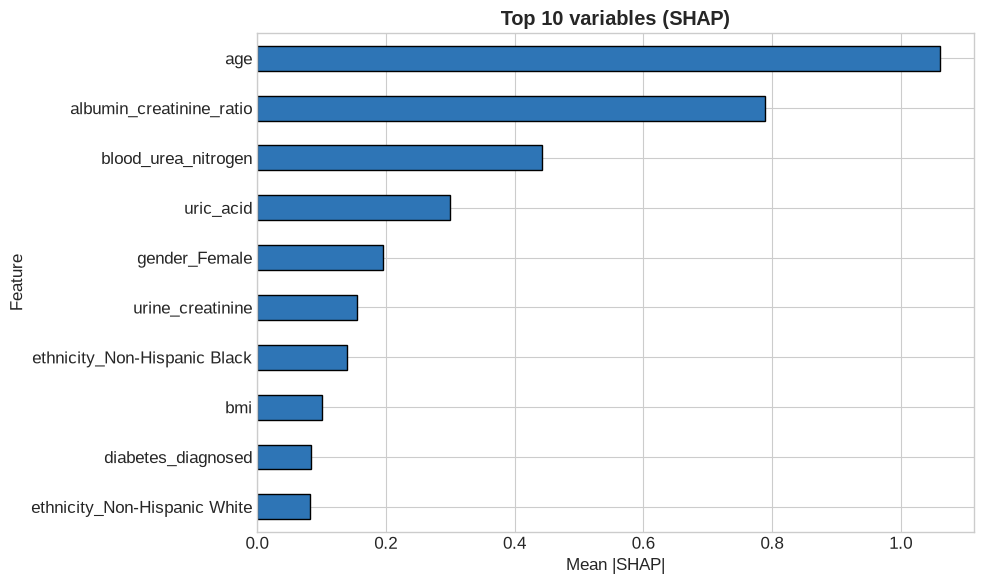

In [48]:
shap_importance = pd.DataFrame(
    {"Feature": all_features, "Mean |SHAP|": np.abs(shap_vals).mean(axis=0)}
).sort_values("Mean |SHAP|", ascending=False)

ax = shap_importance.head(10).plot.barh(
    x="Feature",
    y="Mean |SHAP|",
    legend=False,
    figsize=(10, 6),
    color="#2E75B6",
    edgecolor="black",
)
ax.invert_yaxis()
ax.set_title("Top 10 variables (SHAP)", fontweight="bold")
ax.set_xlabel("Mean |SHAP|")
plt.tight_layout()
plt.show()

## 12.2 Waterfall: paciente con CKD

Paciente con CKD | Prob: 0.9903 | Real: CKD=1


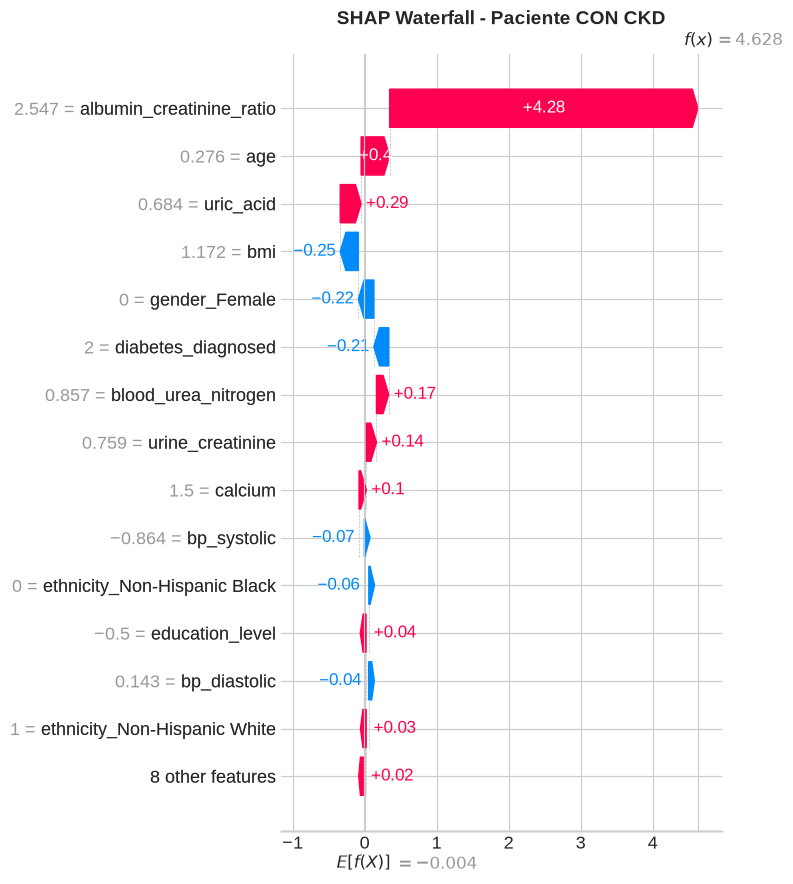

In [49]:
idx_ckd = int(np.argmax(y_test.values))
print(
    f"Paciente con CKD | Prob: {y_prob[idx_ckd]:.4f} | Real: CKD={y_test.iloc[idx_ckd]}"
)

plot_waterfall(
    shap_vals[idx_ckd],
    base_val,
    X_test_prep[idx_ckd],
    all_features,
    "SHAP Waterfall - Paciente CON CKD",
)

## 12.3 Waterfall: paciente sin CKD

Paciente sin CKD | Prob: 0.0458 | Real: CKD=0


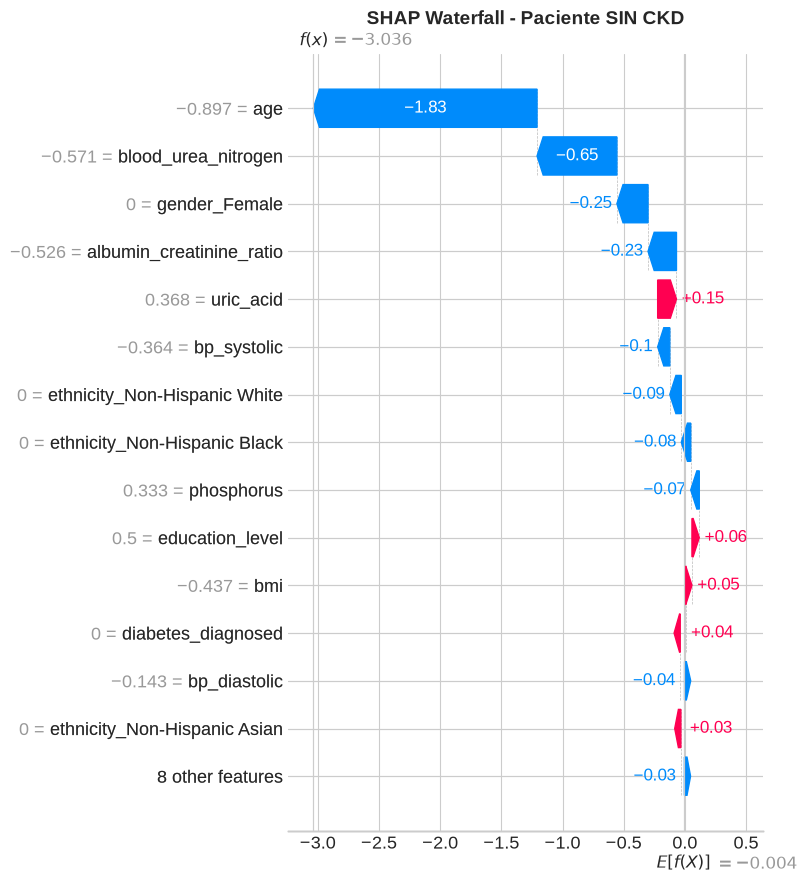

In [50]:
idx_no = int(np.argmin(y_test.values))
print(
    f"Paciente sin CKD | Prob: {y_prob[idx_no]:.4f} | Real: CKD={y_test.iloc[idx_no]}"
)

plot_waterfall(
    shap_vals[idx_no],
    base_val,
    X_test_prep[idx_no],
    all_features,
    "SHAP Waterfall - Paciente SIN CKD",
)

## 12.4 Waterfall: paciente borderline


Paciente borderline | Prob: 0.5021 | Real: CKD=0


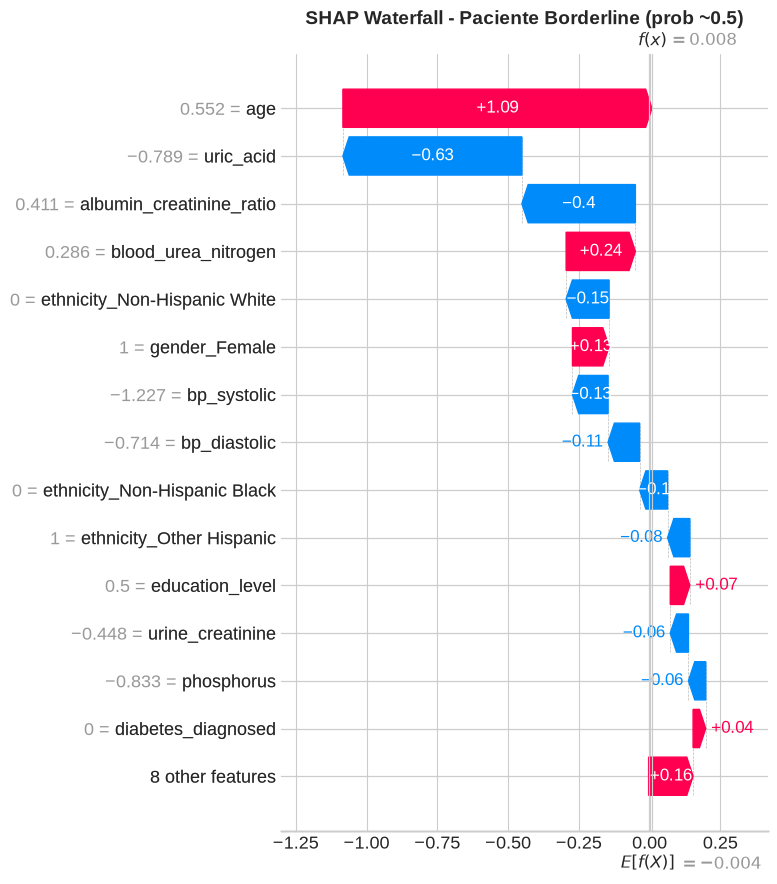

In [51]:
idx_border = np.argmin(np.abs(y_prob - 0.5))
print(
    f"Paciente borderline | Prob: {y_prob[idx_border]:.4f} | Real: CKD={y_test.iloc[idx_border]}"
)

plot_waterfall(
    shap_vals[idx_border],
    base_val,
    X_test_prep[idx_border],
    all_features,
    "SHAP Waterfall - Paciente Borderline (prob ~0.5)",
)

# 13. Redes Neuronales (TensorFlow/Keras)

Comparacion de dos arquitecturas de redes neuronales para clasificar ERC:

- **Somera**: 1 capa oculta (64 neuronas)
- **Profunda**: 4 capas ocultas (128-64-32-16)

Ambas se entrenan sobre los datos balanceados con SMOTE (`X_train_bal`), con 200 epochs, **EarlyStopping** y **decay exponencial** del learning rate. Metrica de evaluacion: **accuracy**.

In [52]:
import tensorflow as tf
from tensorflow.keras import callbacks, layers, models, optimizers
from tensorflow.keras.optimizers.schedules import ExponentialDecay

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow:", tf.__version__)
print("X_train_bal:", X_train_bal.shape, "| y_train_bal:", y_train_bal.shape)
print("X_test_prep:", X_test_prep.shape, "| y_test:", y_test.shape)

I0000 00:00:1787244001.226982  319063 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787244001.227364  319063 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787244001.259062  319063 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.21.0
X_train_bal: (4518, 22) | y_train_bal: (4518,)
X_test_prep: (1089, 22) | y_test: (1089,)


I0000 00:00:1787244002.628047  319063 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787244002.628303  319063 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [53]:
BATCH = 32
EPOCHS = 200
VAL_SPLIT = 0.2

decay_steps = int((len(X_train_bal) * (1 - VAL_SPLIT)) // BATCH)

lr_schedule = ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=decay_steps,
    decay_rate=0.9,
    staircase=True,
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    min_delta=1e-4,
    restore_best_weights=True,
    verbose=1,
)

print(
    f"Decay steps/epoch: {decay_steps} | lr inicial: {lr_schedule.initial_learning_rate}"
)

Decay steps/epoch: 112 | lr inicial: 0.001


## 13.1 Arquitectura Somera
- 1 Única capa oculta

In [54]:
shallow = models.Sequential(
    [
        layers.Input(shape=(X_train_bal.shape[1],)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

shallow.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
shallow.summary()

shallow.fit(
    X_train_bal,
    y_train_bal,
    batch_size=BATCH,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=2,
)

E0000 00:00:1787244002.829086  319063 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787244002.853511  319063 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
113/113 - 1s - 6ms/step - accuracy: 0.6718 - loss: 0.6005 - val_accuracy: 0.7345 - val_loss: 0.5260
Epoch 2/200
113/113 - 0s - 1ms/step - accuracy: 0.7609 - loss: 0.4994 - val_accuracy: 0.7588 - val_loss: 0.4866
Epoch 3/200
113/113 - 0s - 1ms/step - accuracy: 0.7756 - loss: 0.4649 - val_accuracy: 0.7588 - val_loss: 0.4729
Epoch 4/200
113/113 - 0s - 1ms/step - accuracy: 0.7759 - loss: 0.4627 - val_accuracy: 0.7622 - val_loss: 0.4652
Epoch 5/200
113/113 - 0s - 1ms/step - accuracy: 0.7905 - loss: 0.4505 - val_accuracy: 0.7666 - val_loss: 0.4595
Epoch 6/200
113/113 - 0s - 1ms/step - accuracy: 0.7842 - loss: 0.4455 - val_accuracy: 0.7721 - val_loss: 0.4549
Epoch 7/200
113/113 - 0s - 1ms/step - accuracy: 0.7869 - loss: 0.4467 - val_accuracy: 0.7743 - val_loss: 0.4512
Epoch 8/200
113/113 - 0s - 1ms/step - accuracy: 0.7878 - loss: 0.4401 - val_accuracy: 0.7799 - val_loss: 0.4482
Epoch 9/200
113/113 - 0s - 1ms/step - accuracy: 0.7903 - loss: 0.4392 - val_accuracy: 0.7821 - val_loss:

## 13.2 Arquitectura Profunda
- 4 Capas Profundas

In [55]:
deep = models.Sequential(
    [
        layers.Input(shape=(X_train_bal.shape[1],)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ]
)

deep.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
deep.summary()

deep.fit(
    X_train_bal,
    y_train_bal,
    batch_size=BATCH,
    epochs=EPOCHS,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=1,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7421 - loss: 0.5390 - val_accuracy: 0.7754 - val_loss: 0.4675
Epoch 2/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7878 - loss: 0.4545 - val_accuracy: 0.8031 - val_loss: 0.4383
Epoch 3/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8002 - loss: 0.4330 - val_accuracy: 0.8042 - val_loss: 0.4269
Epoch 4/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8094 - loss: 0.4155 - val_accuracy: 0.8053 - val_loss: 0.4272
Epoch 5/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8121 - loss: 0.4063 - val_accuracy: 0.8075 - val_loss: 0.4259
Epoch 6/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8221 - loss: 0.3957 - val_accuracy: 0.8108 - val_loss: 0.4217
Epoch 7/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8365 - loss: 0.3834 - val_accuracy: 0.8053 - val_loss: 0.4253
Epoch 8/200
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8395 - loss: 0.3756 - val_accu

## 13.3 Arquitectura Optimizada (KerasTuner)
- Búsqueda RandomSearch: capas, unidades, dropout, learning rate y batch


In [56]:
import keras_tuner as kt


def build_nn(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train_bal.shape[1],)))
    n_layers = hp.Int("n_layers", 1, 4)
    for i in range(n_layers):
        units = hp.Choice(f"units_{i}", [32, 64, 128, 256])
        model.add(layers.Dense(units, activation="relu"))
        dropout = hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1)
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


tuner = kt.RandomSearch(
    build_nn,
    objective="val_accuracy",
    max_trials=15,
    executions_per_trial=1,
    directory="kt_dir",
    project_name="erc_nn",
    overwrite=True,
    seed=42,
)

tuner.search(
    X_train_bal,
    y_train_bal,
    batch_size=BATCH,
    epochs=100,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=0,
)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Mejores hiperparametros: {best_hp.values}")
print(f"Mejor val_accuracy: {tuner.oracle.get_best_trials(1)[0].score:.4f}")

best_nn = build_nn(best_hp)
best_nn.fit(
    X_train_bal,
    y_train_bal,
    batch_size=BATCH,
    epochs=100,
    validation_split=VAL_SPLIT,
    callbacks=[early_stop],
    verbose=0,
)

Epoch 61: early stopping
Restoring model weights from the end of the best epoch: 46.
Epoch 78: early stopping
Restoring model weights from the end of the best epoch: 63.
Restoring model weights from the end of the best epoch: 93.
Epoch 74: early stopping
Restoring model weights from the end of the best epoch: 59.
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 2.
Restoring model weights from the end of the best epoch: 96.
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 20.
Epoch 34: early stopping
Restoring model weights from the end of the best epoch: 19.
Epoch 85: early stopping
Restoring model weights from the end of the best epoch: 70.
Epoch 46: early stopping
Restoring model weights from the end of the best epoch: 31.
Epoch 94: early stopping
Restoring model weights from the end of the best epoch: 79.
Epoch 17: early stopping
Restoring model weights from the end of the best epoch: 2.
Epoch 28: early stopping
Restori

## 13.4 Evaluación en TEST: AUC-ROC para las arquitecturas


In [57]:
nombres_nn = {
    "Somera (1 capa)": shallow,
    "Profunda (4 capas)": deep,
    "Optimizada (KerasTuner)": best_nn,
}
comparacion = {}
for nombre, model in nombres_nn.items():
    proba = model.predict(X_test_prep, verbose=0)
    y_pred = (proba >= 0.5).astype(int).ravel()
    comparacion[nombre] = {
        "AUC-test": roc_auc_score(y_test, proba.ravel()),
        "Acc-test": accuracy_score(y_test, y_pred),
    }
    print(f"\n===== {nombre} =====")
    print(f"AUC-ROC TEST: {comparacion[nombre]['AUC-test']:.4f}")
    print(f"Accuracy TEST: {comparacion[nombre]['Acc-test']:.4f}")
    print(classification_report(y_test, y_pred, digits=4))
    print("Matriz de confusion:")
    print(confusion_matrix(y_test, y_pred))


===== Somera (1 capa) =====
AUC-ROC TEST: 0.8511
Accuracy TEST: 0.7668
              precision    recall  f1-score   support

           0     0.7843    0.7593    0.7716       565
           1     0.7491    0.7748    0.7617       524

    accuracy                         0.7668      1089
   macro avg     0.7667    0.7671    0.7667      1089
weighted avg     0.7673    0.7668    0.7668      1089

Matriz de confusion:
[[429 136]
 [118 406]]

===== Profunda (4 capas) =====
AUC-ROC TEST: 0.8688
Accuracy TEST: 0.7870
              precision    recall  f1-score   support

           0     0.8011    0.7841    0.7925       565
           1     0.7724    0.7901    0.7811       524

    accuracy                         0.7870      1089
   macro avg     0.7867    0.7871    0.7868      1089
weighted avg     0.7873    0.7870    0.7870      1089

Matriz de confusion:
[[443 122]
 [110 414]]

===== Optimizada (KerasTuner) =====
AUC-ROC TEST: 0.8708
Accuracy TEST: 0.7897
              precision    reca

In [58]:
clasicos = {
    "Logistic Reg.": LogisticRegression(max_iter=1000, random_state=42).fit(
        X_train_bal, y_train_bal
    ),
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "XGBoost (tuned)": xgb_grid.best_estimator_,
}
for nombre, model in clasicos.items():
    proba = model.predict_proba(X_test_prep)[:, 1]
    y_pred = (proba >= 0.5).astype(int)
    comparacion[nombre] = {
        "AUC-test": roc_auc_score(y_test, proba),
        "Acc-test": accuracy_score(y_test, y_pred),
    }
    print(f"\n===== {nombre} =====")
    print(f"AUC-ROC TEST: {comparacion[nombre]['AUC-test']:.4f}")
    print(f"Accuracy TEST: {comparacion[nombre]['Acc-test']:.4f}")


===== Logistic Reg. =====
AUC-ROC TEST: 0.8347
Accuracy TEST: 0.7456

===== Random Forest (tuned) =====
AUC-ROC TEST: 0.8692
Accuracy TEST: 0.7769

===== XGBoost (tuned) =====
AUC-ROC TEST: 0.8804
Accuracy TEST: 0.7925


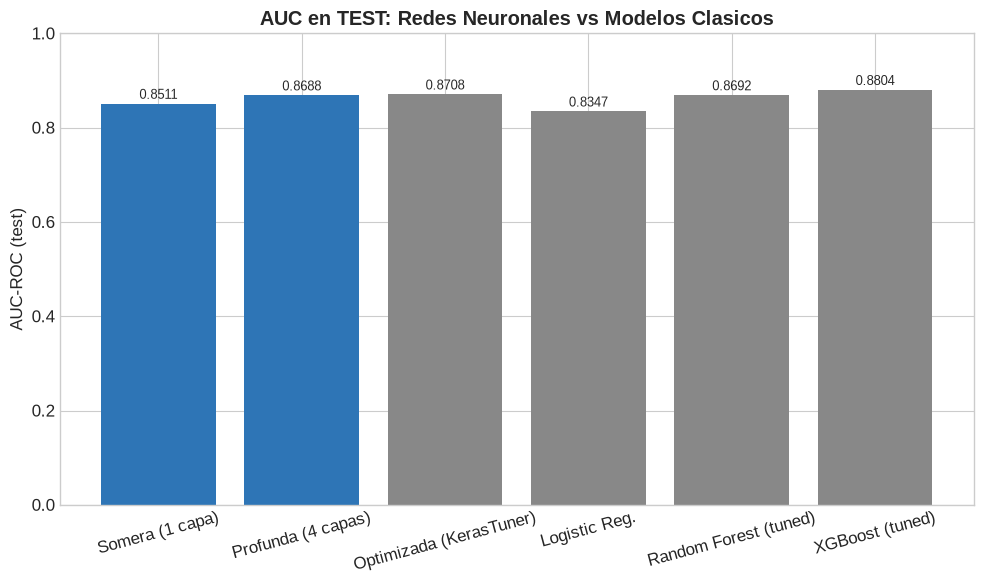

In [59]:
plt.figure(figsize=(10, 6))
names = list(comparacion.keys())
vals = [comparacion[n]["AUC-test"] for n in names]
colors = ["#2E75B6" if i < 2 else "#888" for i in range(len(names))]
bars = plt.bar(names, vals, color=colors)
plt.ylim(0, 1)
plt.ylabel("AUC-ROC (test)")
plt.title("AUC en TEST: Redes Neuronales vs Modelos Clasicos", fontweight="bold")
for bar, v in zip(bars, vals):
    plt.text(
        bar.get_x() + bar.get_width() / 2, v + 0.01, f"{v:.4f}", ha="center", fontsize=9
    )
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [60]:
tabla = pd.DataFrame(comparacion).T.round(4)
tabla.columns = ["AUC-ROC (test)", "Accuracy (test)"]
print(tabla.sort_values("AUC-ROC (test)", ascending=False))

                         AUC-ROC (test)  Accuracy (test)
XGBoost (tuned)                  0.8804           0.7925
Optimizada (KerasTuner)          0.8708           0.7897
Random Forest (tuned)            0.8692           0.7769
Profunda (4 capas)               0.8688           0.7870
Somera (1 capa)                  0.8511           0.7668
Logistic Reg.                    0.8347           0.7456


# 14. Optimización de Umbral (enfoque Preventivo)
- En screening es mas barato mandar a un sano a confirmarse que decirle a un enfermo que esta sano. El umbral se elige en VALIDACION (pre-SMOTE) y se aplica al test UNA sola vez.

In [61]:
if best_name != "XGBoost (optimizado)":
    print(f"AVISO: best_model = {best_name}; el ajuste de umbral supone XGBoost")

# 1) Validacion del train PRE-SMOTE (desbalanceado ~43%, como el test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_prep, y_train, test_size=0.2, stratify=y_train, random_state=42
)
print(
    f"VALIDACION: {len(X_tr)} train + {len(X_val)} val | "
    f"CKD val: {(y_val == 1).mean():.3f}"
)

# 2) SMOTE SOLO sobre el 80% de train
smote_v = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = smote_v.fit_resample(X_tr, y_tr)

VALIDACION: 3484 train + 871 val | CKD val: 0.481


In [62]:
# 3) Re-entrenar XGBoost con los hiperparametros optimos del grid
xgb_params_f = params_sin_prefijo(xgb_grid)
xgb_thr = XGBClassifier(**xgb_params_f)
xgb_thr.fit(X_tr_bal, y_tr_bal)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [63]:
# 4) Curva ROC sobre VALIDACION para elegir umbrales
val_prob = xgb_thr.predict_proba(X_val)[:, 1]
fpr_v, tpr_v, thr_v = roc_curve(y_val, val_prob)

# Youden's J: maximiza sens + spec
j_idx = int(np.argmax(tpr_v - fpr_v))
thr_youden = float(thr_v[j_idx])
# Clinico: sens >= 0.85 maximizando especificidad
mask = tpr_v >= 0.85
c_idx = int(np.argmin(fpr_v[mask]))
thr_clin = float(thr_v[mask][c_idx])
print(f"{'Umbral':<14}{'Valor':>8}{'Sens':>8}{'Spec':>8}")
print(f"{'Youden J':<14}{thr_youden:>8.3f}{tpr_v[j_idx]:>8.3f}{1 - fpr_v[j_idx]:>8.3f}")
print(
    f"{'Clinico':<14}{thr_clin:>8.3f}"
    f"{tpr_v[mask][c_idx]:>8.3f}{1 - fpr_v[mask][c_idx]:>8.3f}"
)

Umbral           Valor    Sens    Spec
Youden J         0.511   0.780   0.816
Clinico          0.378   0.857   0.730


In [64]:
# 5) Aplicar los 3 umbrales al TEST con y_prob del modelo original
umbrales = {
    "Default (0.50)": 0.5,
    "Youden": thr_youden,
    "Clinico (sens>=0.85)": thr_clin,
}
filas = []
for nombre, umbral in umbrales.items():
    y_pred = (y_prob >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    f1 = 2 * tp / (2 * tp + fp + fn)
    filas.append(
        {
            "Umbral": nombre,
            "Valor": umbral,
            "Sens": sens,
            "Spec": spec,
            "F1": f1,
            "FN": fn,
            "FP": fp,
        }
    )

tabla_umbral = pd.DataFrame(filas).set_index("Umbral").round(3)
print(tabla_umbral)

                      Valor   Sens   Spec     F1   FN   FP
Umbral                                                    
Default (0.50)        0.500  0.784  0.800  0.784  113  113
Youden                0.511  0.773  0.809  0.781  119  108
Clinico (sens>=0.85)  0.378  0.870  0.701  0.794   68  169


## 14.1 Matrices de Confusión

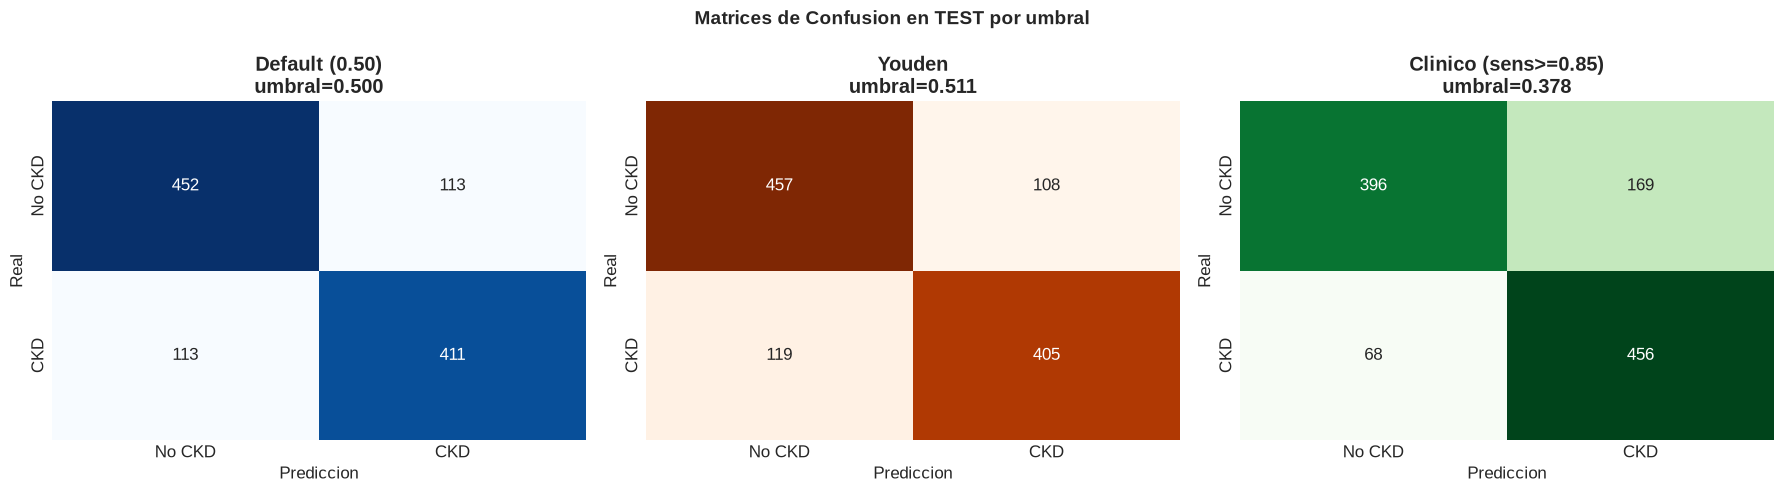

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ["Blues", "Oranges", "Greens"]
for ax, (nombre, umbral), cmap in zip(axes, umbrales.items(), cmaps):
    y_pred = (y_prob >= umbral).astype(int)
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=ax,
        xticklabels=["No CKD", "CKD"],
        yticklabels=["No CKD", "CKD"],
        cbar=False,
    )
    ax.set_title(f"{nombre}\numbral={umbral:.3f}", fontweight="bold")
    ax.set_xlabel("Prediccion")
    ax.set_ylabel("Real")
plt.suptitle("Matrices de Confusion en TEST por umbral", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 14.2 Curva ROC-AUC y puntos de operación

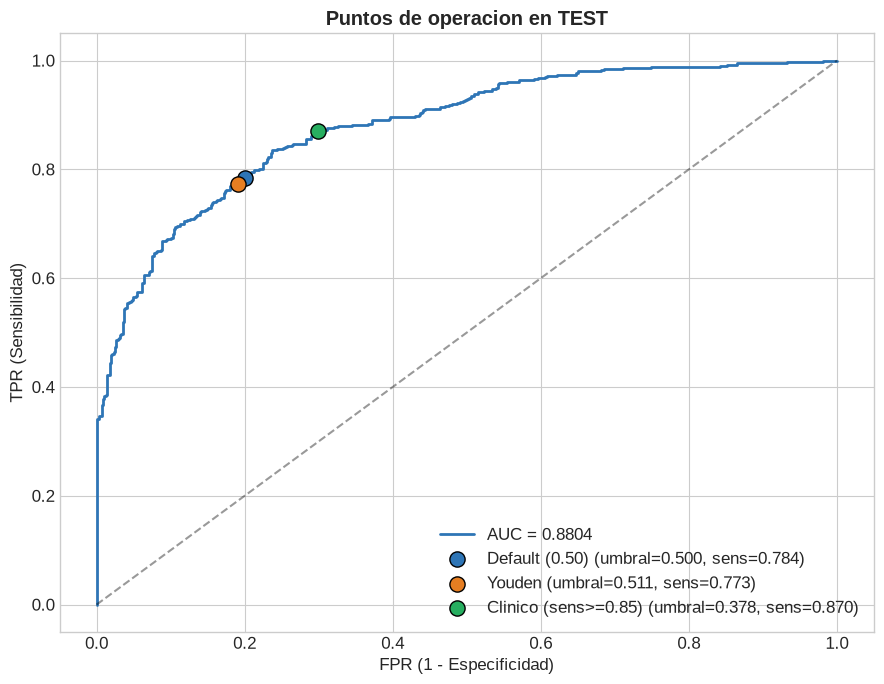

In [66]:
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(9, 7))
plt.plot(
    fpr_t,
    tpr_t,
    color="#2E75B6",
    lw=2,
    label=f"AUC = {roc_auc_score(y_test, y_prob):.4f}",
)
plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
colores_pt = {
    "Default (0.50)": "#2E75B6",
    "Youden": "#E67E22",
    "Clinico (sens>=0.85)": "#27AE60",
}
for nombre, umbral in umbrales.items():
    y_pred = (y_prob >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp / (tp + fn)
    spec = tn / (tn + fp)
    plt.scatter(
        1 - spec,
        sens,
        s=120,
        zorder=5,
        color=colores_pt[nombre],
        edgecolor="black",
        label=f"{nombre} (umbral={umbral:.3f}, sens={sens:.3f})",
    )
plt.xlabel("FPR (1 - Especificidad)")
plt.ylabel("TPR (Sensibilidad)")
plt.title("Puntos de operacion en TEST", fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
default = tabla_umbral.loc["Default (0.50)"]
clin = tabla_umbral.loc["Clinico (sens>=0.85)"]
fn_ahorro = int(default["FN"] - clin["FN"])
fp_extra = int(clin["FP"] - default["FP"])
print(
    f"Umbral clinico vs default: {fn_ahorro} falsos negativos MENOS "
    f"({default['FN']} -> {clin['FN']}) a cambio de {fp_extra} falsos "
    f"positivos adicionales ({default['FP']} -> {clin['FP']})."
)

Umbral clinico vs default: 45 falsos negativos MENOS (113.0 -> 68.0) a cambio de 56 falsos positivos adicionales (113.0 -> 169.0).



---
# 15. Aplicación — Predicción sobre pacientes simulados

Aplicamos el modelo `best_model` a 5 perfiles clinicos ficticios pero realistas para
ilustrar la utilidad del modelo en la practica. Cada paciente tiene valores para las
18 columnas crudas de `X_test`. El pipeline central `prepare_data` (seccion 8) codifica
todas las columnas y luego elimina las features `gender_Male` y
`bicarbonate` por nombre de feature encodeada.

El flujo por paciente es: `transform()` (preprocesador unico + filtrado ya ajustado)
-> `best_model.predict_proba()` -> aplicar los 3 umbrales (default 0.50, Youden,
clinico). El analisis se apoya en un grafico de barras de probabilidad y un
beeswarm SHAP para ver que variables empujaron cada prediccion.


In [68]:
pacientes = pd.read_csv("../data/pacientes_simulados.csv")
pacientes.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   nombre                    5 non-null      str    
 1   age                       5 non-null      int64  
 2   gender                    5 non-null      str    
 3   ethnicity                 5 non-null      str    
 4   education_level           5 non-null      int64  
 5   poverty_income_ratio      5 non-null      float64
 6   bmi                       5 non-null      float64
 7   bp_systolic               5 non-null      int64  
 8   bp_diastolic              5 non-null      int64  
 9   blood_urea_nitrogen       5 non-null      int64  
 10  albumin_serum             5 non-null      float64
 11  phosphorus                5 non-null      float64
 12  bicarbonate               5 non-null      int64  
 13  calcium                   5 non-null      float64
 14  uric_acid                

In [69]:
pacientes["albumin_creatinine_ratio"] = np.log1p(pacientes["albumin_creatinine_ratio"])
nombres = pacientes["nombre"].tolist()
# Ordenar igual que X_test (no usar la columna "nombre")
pacientes_X = pacientes[X_test.columns].copy()

# 1) Preprocesar con el MISMO pipeline unico ya ajustado
X_pac = transform(pacientes_X)

# 2) Probabilidades del mejor modelo
proba_pac = best_model.predict_proba(X_pac)[:, 1]

# 3) SHAP del modelo sobre los pacientes
sv_pac = explainer.shap_values(X_pac)
if isinstance(sv_pac, list):
    sv_pac = sv_pac[1]
    base_pac = explainer.expected_value[1]
else:
    base_pac = explainer.expected_value

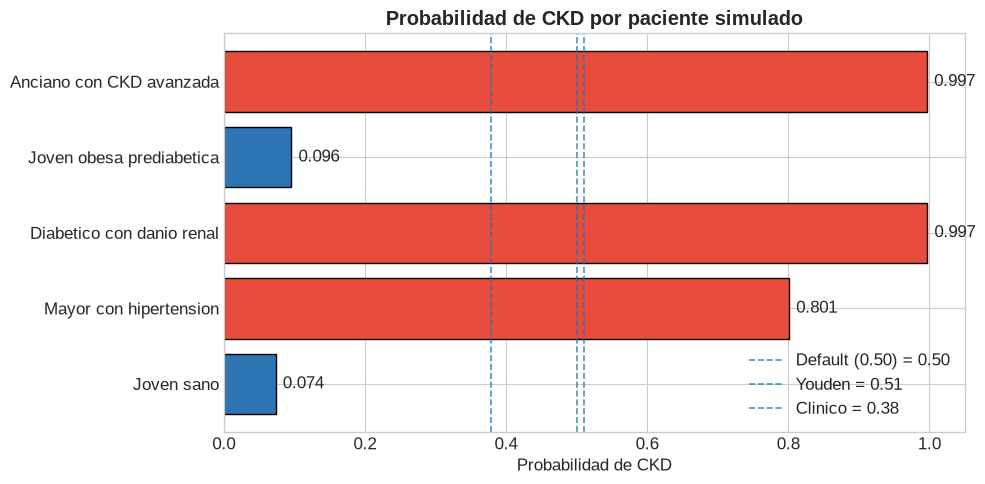

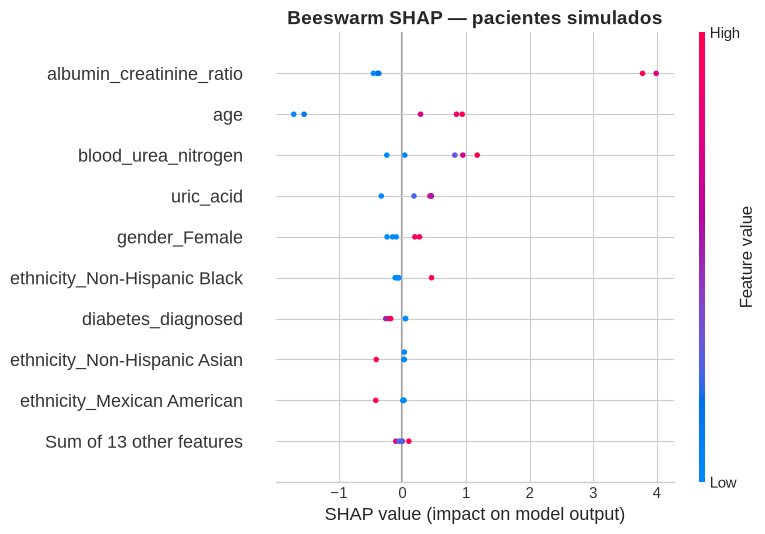

In [70]:
# 4) Barras de probabilidad con los 3 umbrales
umbrales_pac = {
    "Default (0.50)": 0.5,
    "Youden": thr_youden,
    "Clinico": thr_clin,
}
colores = ["#E74C3C" if p >= thr_clin else "#2E75B6" for p in proba_pac]
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(nombres, proba_pac, color=colores, edgecolor="black")
for bar, prob in zip(bars, proba_pac):
    ax.text(prob + 0.01, bar.get_y() + bar.get_height() / 2, f"{prob:.3f}", va="center")
for nombre, umbral in umbrales_pac.items():
    ax.axvline(umbral, ls="--", lw=1.2, alpha=0.8, label=f"{nombre} = {umbral:.2f}")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Probabilidad de CKD")
ax.set_title("Probabilidad de CKD por paciente simulado", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# 5) Beeswarm: contribucion SHAP de cada variable por paciente
expl_pac = shap.Explanation(
    values=sv_pac,
    base_values=base_pac,
    data=X_pac,
    feature_names=all_features,
)
plt.figure(figsize=(11, 7))
shap.plots.beeswarm(expl_pac, show=False)
plt.title("Beeswarm SHAP — pacientes simulados", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
# 16. Aplicación comparativa: pacientes simulados SIN ACR

Mismos 5 pacientes, pero quitando `albumin_creatinine_ratio`. Reutilizamos el
modelo de sensibilidad (`xgb_sens`, entrenado sin ACR en la seccion de analisis
de sensibilidad) y su preprocesador (`prep_sens`). Comparamos probabilidad y
beeswarm SHAP CON vs SIN ACR para ver cuanto depende cada prediccion de la
albuminuria.

In [71]:
# Quitar ACR del DataFrame de pacientes (mismas filas, mismo orden)
pacientes_no_acr = pacientes_X.drop(columns=["albumin_creatinine_ratio"])

# Preprocesar con el pipeline de sensibilidad (ya ajustado sin ACR)
X_pac_no_acr = transform_s(pacientes_no_acr)

# Probabilidad del modelo sin ACR (xgb_sens de la seccion de sensibilidad)
proba_no_acr = xgb_sens.predict_proba(X_pac_no_acr)[:, 1]

# SHAP del modelo SIN ACR
explainer_sens = shap.TreeExplainer(xgb_sens)
sv_sens = explainer_sens.shap_values(X_pac_no_acr)
if isinstance(sv_sens, list):
    sv_sens = sv_sens[1]
    base_sens = explainer_sens.expected_value[1]
else:
    base_sens = explainer_sens.expected_value
all_features_sens = all_features_s

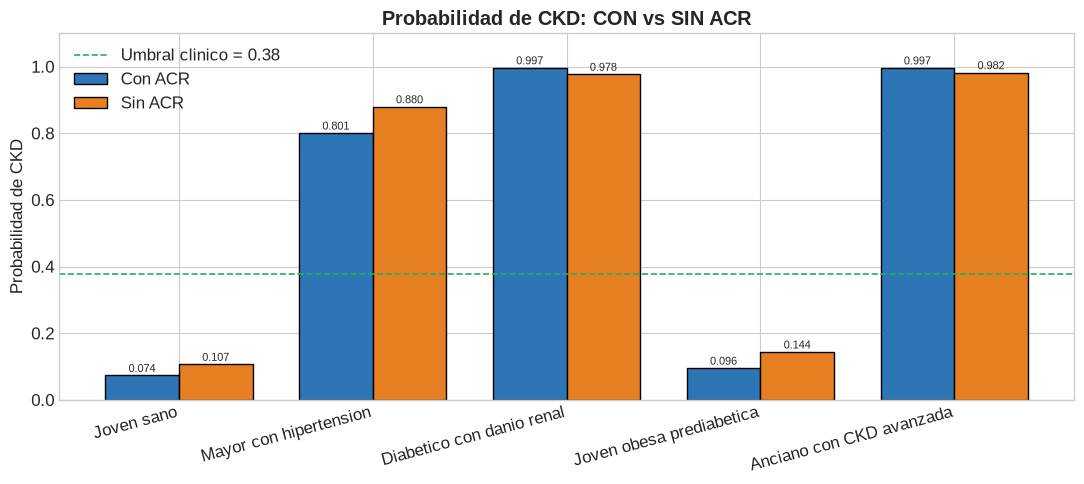

In [72]:
# Barras agrupadas: probabilidad CON vs SIN ACR
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(nombres))
w = 0.38
b1 = ax.bar(
    x - w / 2, proba_pac, w, label="Con ACR", color="#2E75B6", edgecolor="black"
)
b2 = ax.bar(
    x + w / 2, proba_no_acr, w, label="Sin ACR", color="#E67E22", edgecolor="black"
)
for bars, probs in ((b1, proba_pac), (b2, proba_no_acr)):
    for bar, prob in zip(bars, probs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            prob + 0.01,
            f"{prob:.3f}",
            ha="center",
            fontsize=8,
        )
ax.axhline(
    thr_clin, ls="--", lw=1.2, color="#27AE60", label=f"Umbral clinico = {thr_clin:.2f}"
)
# Marcar pacientes donde cambia la decision clinica
for i, nombre in enumerate(nombres):
    cambia = (proba_pac[i] >= thr_clin) != (proba_no_acr[i] >= thr_clin)
    if cambia:
        ax.text(
            x[i],
            max(proba_pac[i], proba_no_acr[i]) + 0.04,
            "cambia",
            ha="center",
            fontweight="bold",
            color="#E74C3C",
        )
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=15, ha="right")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Probabilidad de CKD")
ax.set_title("Probabilidad de CKD: CON vs SIN ACR", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

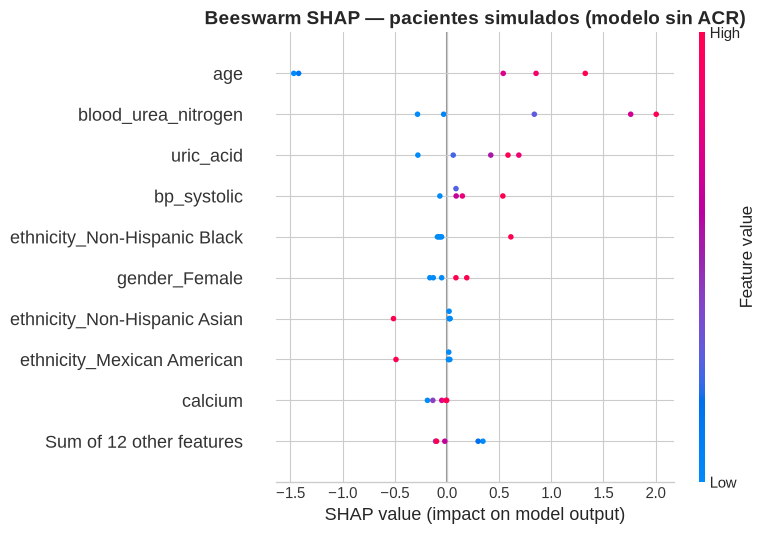

In [73]:
# Beeswarm del modelo SIN ACR
expl_sens = shap.Explanation(
    values=sv_sens,
    base_values=base_sens,
    data=X_pac_no_acr,
    feature_names=all_features_sens,
)
plt.figure(figsize=(11, 7))
shap.plots.beeswarm(expl_sens, show=False)
plt.title(
    "Beeswarm SHAP — pacientes simulados (modelo sin ACR)",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

---
# 17. Resumen

In [74]:
print(f"Mejor modelo: {best_name}")
print(f"AUC-ROC (test): {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR (test):  {average_precision_score(y_test, y_prob):.4f}")
print("Top 5 variables (SHAP):")
print(shap_importance.head(5)[["Feature", "Mean |SHAP|"]].to_string(index=False))

Mejor modelo: XGBoost (optimizado)
AUC-ROC (test): 0.8804
AUC-PR (test):  0.8881
Top 5 variables (SHAP):
                 Feature  Mean |SHAP|
                     age     1.060824
albumin_creatinine_ratio     0.788417
     blood_urea_nitrogen     0.443235
               uric_acid     0.299035
           gender_Female     0.195194


## 17.1 Limitaciones
- NHANES es transversal (no captura cronicidad de 3 meses KDIGO)
- ACR podria tener fuga parcial si definio ckd_present
- Poblacion estadounidense (requiere validacion externa)
- Se excluyeron eGFR y serum_creatinine para evitar circularidad

## 17.2 Trabajo futuro
- Clasificacion multiclase (G1-G5)
- Sistema jerarquico binario + multiclase
- Validacion con cohortes externas
- Incorporar hemoglobina, cistatina C, HbA1c
- Modelos de progresion temporal
- Despliegue como herramienta clinica